# Tema 1 CC - EDA General + Regresie/Clasificare


1. **PARTEA A - GENERAL**: incarcare date, tipuri de atribute, valori lipsa, distributii, outlieri, redundanta intre features si privire scurta asupra ambelor tinte (`salary` si `vacation`). Aceasta parte poate fi folosita si cand vom face clasificarea separat.
2. **PARTEA B - REGRESIE**: EDA specific pentru `salary`, preprocesare pentru regresie, modele, metrici si submission Kaggle.
3. **PARTEA C - CLASIFICARE**: EDA specific pentru `vacation`, preprocesare pentru clasificare, modele, metrici si submission Kaggle.

In [1]:
# %pip install matplotlib seaborn

import os
import warnings
from pathlib import Path

MPL_CACHE_DIR = Path(".matplotlib_cache")
MPL_CACHE_DIR.mkdir(exist_ok=True)
XDG_CACHE_DIR = Path(".cache")
XDG_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR.resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_DIR.resolve()))

import numpy as np
import pandas as pd

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")

# In etapa curenta rulam doar modelele pastrate in tabelul final; experimentele vechi raman in notebook ca istoric.
RUN_LEGACY_REGRESSION_MODELS = False


# PARTEA A - GENERAL

## A1. Incarcare date si rolul fiecarui fisier

Avem deja fisiere separate, deci **nu impartim manual train-ul in train/validation**.

- `CC_education_economy_train.csv` = antrenare;
- `CC_education_economy_test.csv` = validare 
- `CC_private_test.csv` = test privat pentru Kaggle/submission, fara tinte => testare


In [2]:
DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "CC_education_economy_train.csv"
TEST_PATH = DATA_DIR / "CC_education_economy_test.csv"
PRIVATE_TEST_PATH = DATA_DIR / "CC_private_test.csv"

REGRESSION_TARGET = "salary"
CLASSIFICATION_TARGET = "vacation"
TARGET = REGRESSION_TARGET
OTHER_TARGET = CLASSIFICATION_TARGET

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
private_test_raw = pd.read_csv(PRIVATE_TEST_PATH) if PRIVATE_TEST_PATH.exists() else None

print("train:", train_raw.shape)
print("test local:", test_raw.shape)
if private_test_raw is not None:
    print("private test:", private_test_raw.shape)

display(train_raw.head())


train: (64000, 14)
test local: (16000, 14)
private test: (16000, 13)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,total_days_worked,aggregated_score,skill_bracket,vacation
0,Backend Developer,19,High School,12,Media,Large,USA,Yes,0,203997,4560,-0.723308,mid,Small
1,Backend Developer,4,High School,13,Telecom,Small,Germany,NaN,5,116239,960,-0.481551,high,No Vacation
2,Backend Developer,8,High School,16,Retail,Enterprise,Remote,No,4,145802,1920,-1.533057,high,No Vacation
3,Backend Developer,12,High School,9,Telecom,Enterprise,USA,Hybrid,2,190299,2880,0.527458,mid,Small
4,Backend Developer,14,High School,6,Telecom,Large,UK,Hybrid,4,152679,3360,-0.186280,low,No Vacation


## A2. Tipuri de atribute si valori lipsa

Aici este EDA general: Intelegem coloanele, tipurile si problemele evidente din date. Aceasta sectiune este utila si pentru regresie, si pentru clasificare.


In [3]:
FEATURE_COLS = [c for c in train_raw.columns if c not in [REGRESSION_TARGET, CLASSIFICATION_TARGET]]
NUMERIC_FEATURES_EDA = train_raw[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_FEATURES_EDA = [c for c in FEATURE_COLS if c not in NUMERIC_FEATURES_EDA]

feature_types = pd.DataFrame([
    ("job_title", "categorial nominal", "functie"),
    ("experience_years", "numeric", "experienta"),
    ("education_level", "ordinal/categorial", "nivel educational"),
    ("skills_count", "numeric discret", "numar skill-uri"),
    ("industry", "categorial nominal", "industrie"),
    ("company_size", "ordinal/categorial", "dimensiune companie"),
    ("location", "categorial nominal", "locatie"),
    ("remote_work", "categorial nominal", "are valori lipsa"),
    ("certifications", "numeric discret", "numar certificari"),
    ("total_days_worked", "numeric", "posibil redundant cu experience_years"),
    ("aggregated_score", "numeric continuu", "scor agregat"),
    ("skill_bracket", "ordinal/categorial", "nivel skill-uri"),
    ("salary", "tinta regresie", "nu este feature"),
    ("vacation", "tinta clasificare", "nu este feature"),
], columns=["coloana", "tip", "observatie"])

display(feature_types)

missing_report = pd.DataFrame({
    "missing_count": train_raw.isna().sum(),
    "missing_percent": (train_raw.isna().mean() * 100).round(2),
}).query("missing_count > 0").sort_values("missing_count", ascending=False)

print("Valori lipsa:")
display(missing_report)


,coloana,tip,observatie
0,job_title,categorial nominal,functie
1,experience_years,numeric,experienta
2,education_level,ordinal/categorial,nivel educational
3,skills_count,numeric discret,numar skill-uri
4,industry,categorial nominal,industrie
5,company_size,ordinal/categorial,dimensiune companie
6,location,categorial nominal,locatie
7,remote_work,categorial nominal,are valori lipsa
8,certifications,numeric discret,numar certificari
9,total_days_worked,numeric,posibil redundant cu experience_years


Valori lipsa:


,missing_count,missing_percent
remote_work,19153,29.93


## A3. Statistici si distributii generale pentru features

Statistici pentru numerice si un tabel pentru categorice/ordinale. Graficele de aici sunt generale: ne uitam la plaja valorilor si distributii.


In [4]:
# Statistici numerice cerute: count, mean, std, min, 25%, 50%/median, 75%, max.
numeric_stats = train_raw[NUMERIC_FEATURES_EDA].describe().T.rename(columns={"50%": "median"})
numeric_stats = numeric_stats[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]
display(numeric_stats.round(2))

# Tabel pentru categorice/ordinale: numar non-lipsa si numar valori unice.
cat_stats = pd.DataFrame({
    "non_missing_count": train_raw[CATEGORICAL_FEATURES_EDA].notna().sum(),
    "missing_count": train_raw[CATEGORICAL_FEATURES_EDA].isna().sum(),
    "unique_values_including_missing": train_raw[CATEGORICAL_FEATURES_EDA].nunique(dropna=False),
})
display(cat_stats)

,count,mean,std,min,25%,median,75%,max
experience_years,64000.0,9.97,6.05,0.0,5.00,10.0,15.00,20.00
skills_count,64000.0,11.60,10.74,1.0,5.00,10.0,15.00,69.00
certifications,64000.0,2.51,1.71,0.0,1.00,3.0,4.00,5.00
total_days_worked,64000.0,2393.51,1452.04,-1.0,1200.00,2400.0,3600.00,4800.00
aggregated_score,64000.0,0.00,1.00,-4.8,-0.67,0.0,0.68,4.22


,non_missing_count,missing_count,unique_values_including_missing
job_title,64000,0,12
education_level,64000,0,5
industry,64000,0,10
company_size,64000,0,5
location,64000,0,10
remote_work,44847,19153,4
skill_bracket,64000,0,3


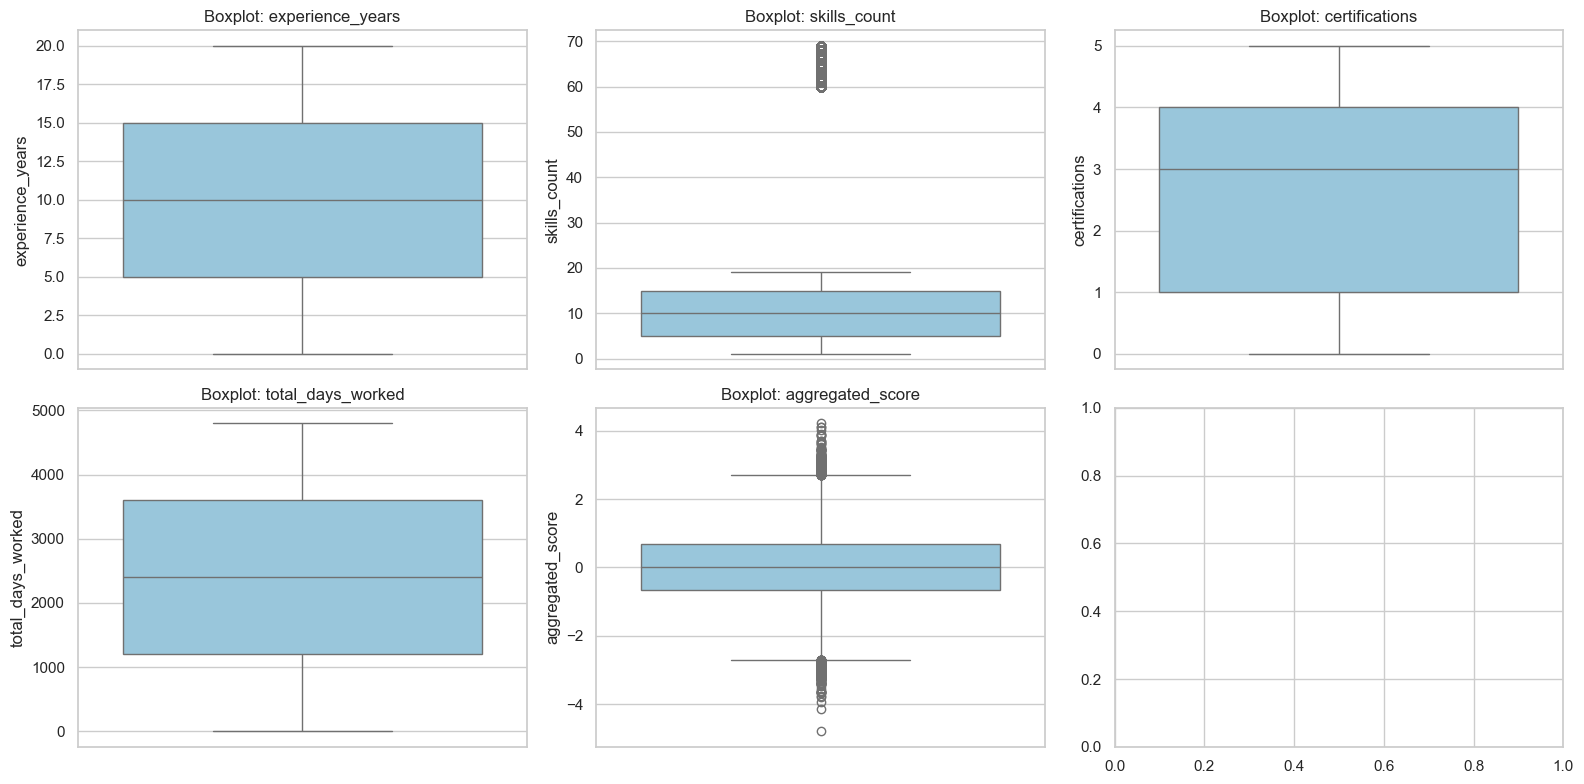

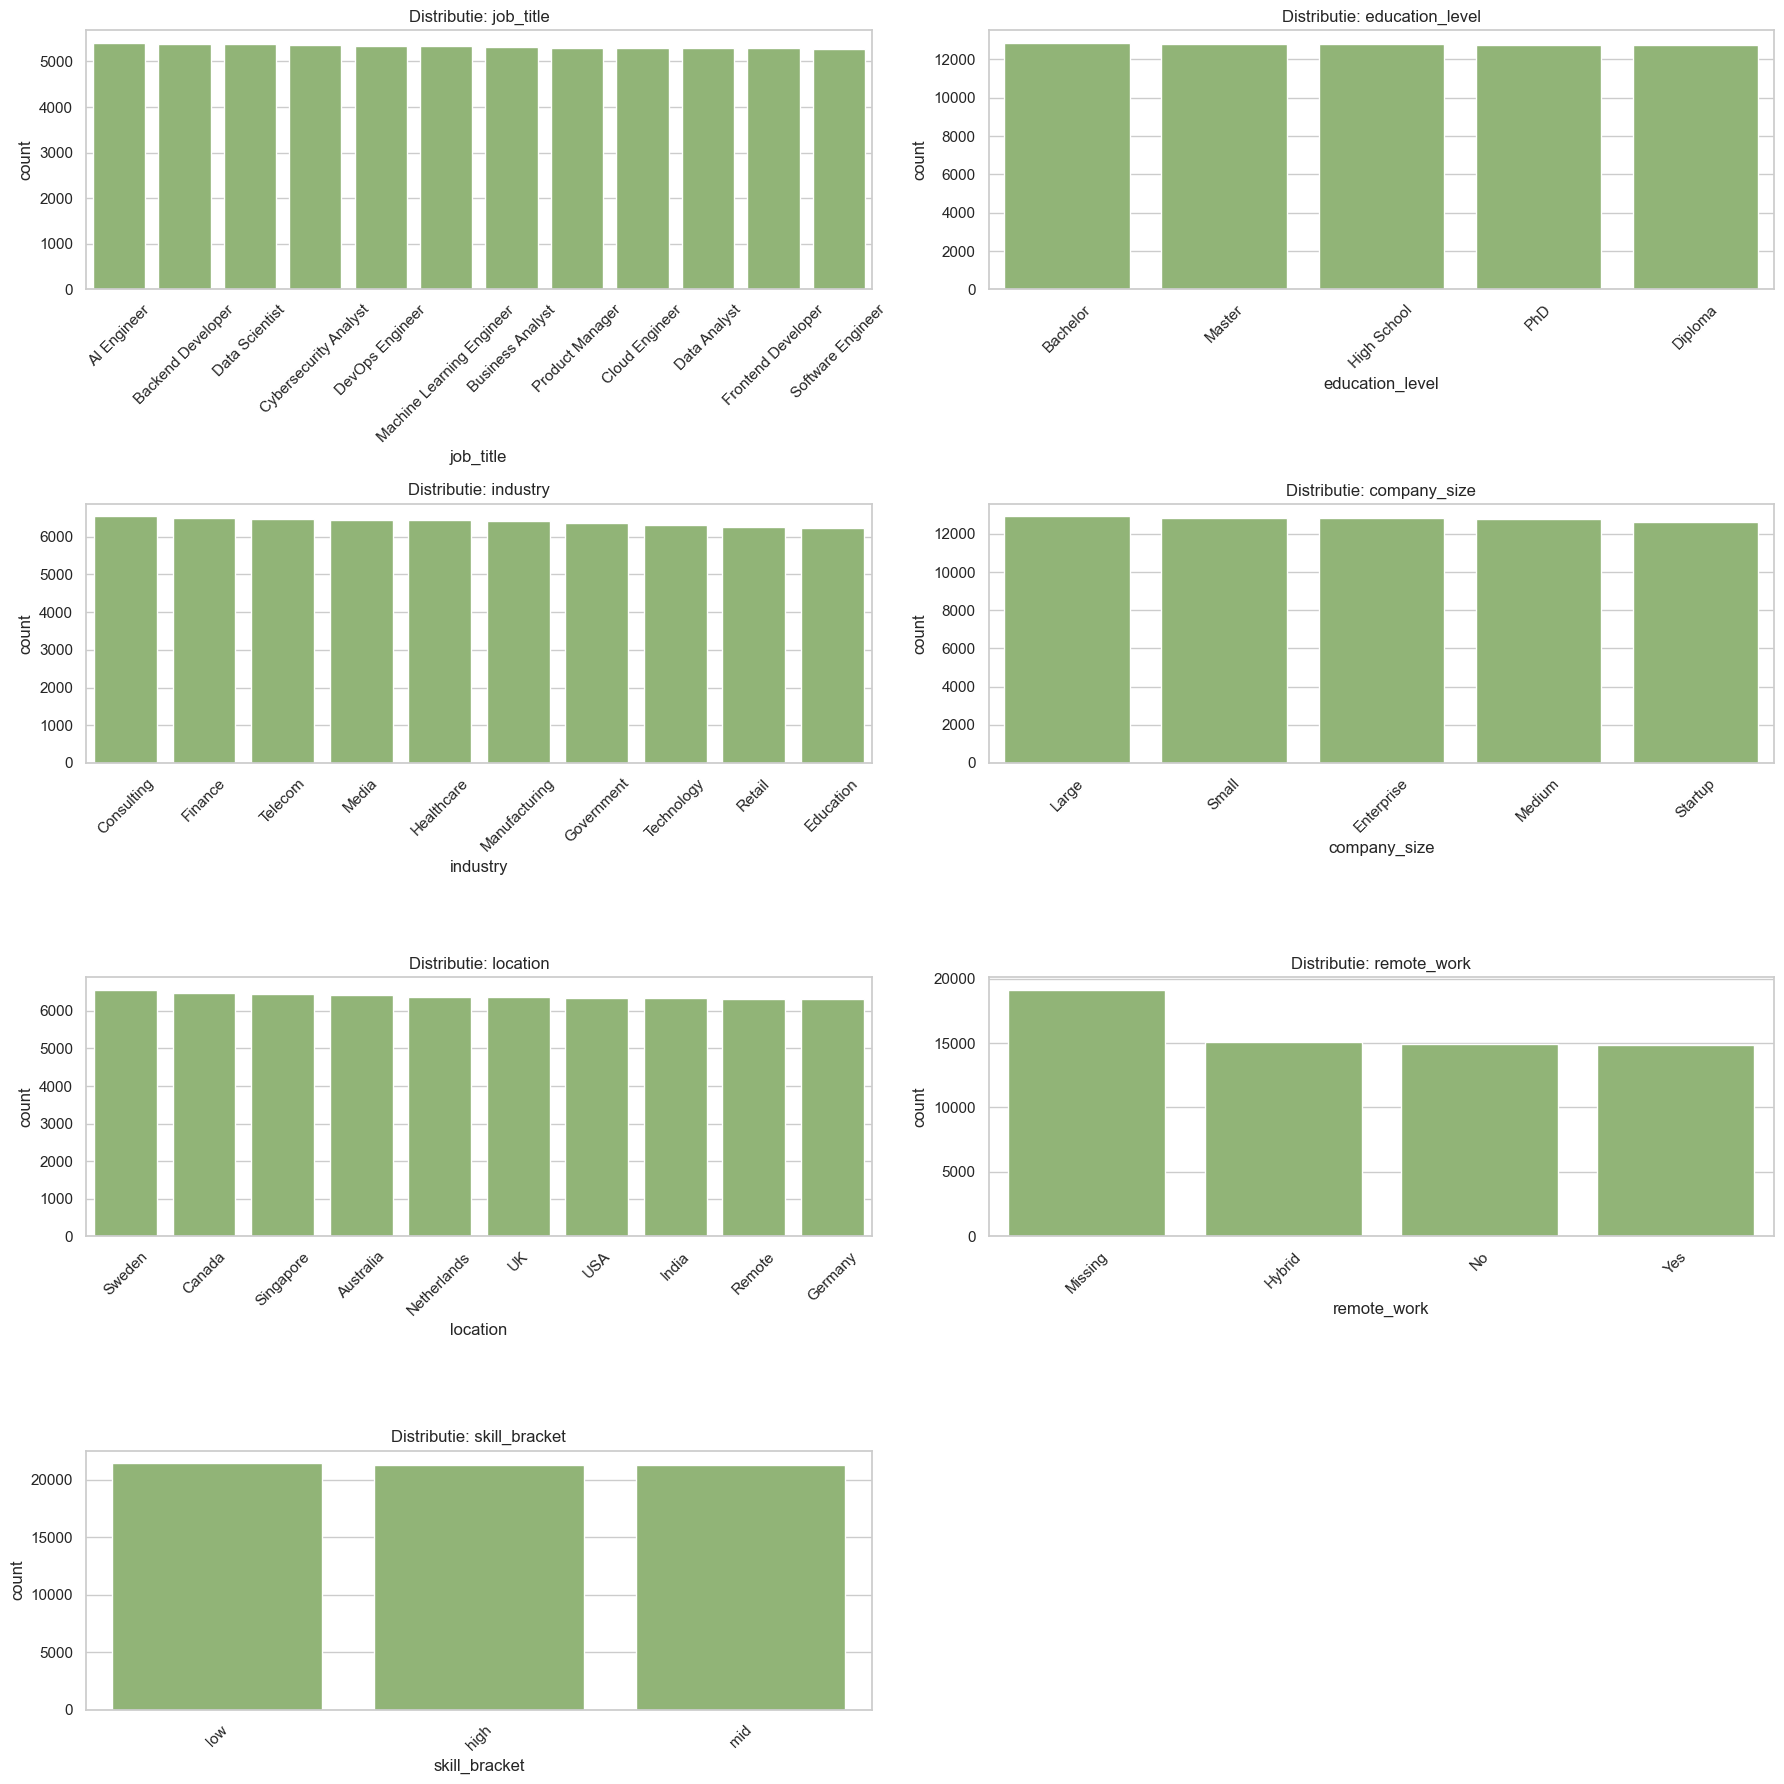

In [5]:
# Vizualizari generale cerute: boxplot pentru numerice si countplot pentru categorice.
# Le grupam ca sa nu depasim recomandarea din PDF de a nu face prea multe grafice EDA.
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    PLOTS_AVAILABLE = True
except ImportError:
    PLOTS_AVAILABLE = False
    print("Pentru grafice ruleaza: %pip install matplotlib seaborn")

if PLOTS_AVAILABLE:
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, col in zip(axes.ravel(), NUMERIC_FEATURES_EDA):
        sns.boxplot(y=train_raw[col], ax=ax, color="#8ecae6")
        ax.set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(4, 2, figsize=(18, 18))
    axes = axes.ravel()
    for ax, col in zip(axes, CATEGORICAL_FEATURES_EDA):
        values = train_raw[col].fillna("Missing").astype(str)
        sns.countplot(x=values, order=values.value_counts().index, ax=ax, color="#90be6d")
        ax.set_title(f"Distributie: {col}")
        ax.tick_params(axis="x", rotation=45)
    for ax in axes[len(CATEGORICAL_FEATURES_EDA):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## A4. Outlieri si redundanta intre features

Aceasta este tot parte generala: identificam valori extreme si features redundante inainte sa alegem modele. Tratamentul exact il aplicam mai jos, in partea de preprocesare.


In [6]:
def iqr_bounds(series: pd.Series, q1=0.25, q3=0.75, multiplier=1.5):
    q_low = series.quantile(q1)
    q_high = series.quantile(q3)
    iqr = q_high - q_low
    return q_low - multiplier * iqr, q_high + multiplier * iqr

outlier_rows = []
for col in NUMERIC_FEATURES_EDA:
    lower, upper = iqr_bounds(train_raw[col])
    mask = (train_raw[col] < lower) | (train_raw[col] > upper)
    outlier_rows.append({
        "feature": col,
        "iqr_lower": lower,
        "iqr_upper": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percent": round(mask.mean() * 100, 2),
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_report)

feature_corr = train_raw[NUMERIC_FEATURES_EDA].corr(numeric_only=True)
display(feature_corr.round(3))

high_corr_pairs = []
for i, c1 in enumerate(NUMERIC_FEATURES_EDA):
    for c2 in NUMERIC_FEATURES_EDA[i + 1:]:
        corr_value = feature_corr.loc[c1, c2]
        if abs(corr_value) >= 0.9:
            high_corr_pairs.append((c1, c2, corr_value))

print("Perechi numerice foarte corelate:")
display(pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"]).round(3))


,feature,iqr_lower,iqr_upper,outlier_count,outlier_percent
1,skills_count,-10.000000,30.000000,1909,2.98
4,aggregated_score,-2.701801,2.706318,437,0.68
0,experience_years,-10.000000,30.000000,0,0.00
2,certifications,-3.500000,8.500000,0,0.00
3,total_days_worked,-2400.000000,7200.000000,0,0.00


,experience_years,skills_count,certifications,total_days_worked,aggregated_score
experience_years,1.000,0.003,0.002,1.000,-0.001
skills_count,0.003,1.000,0.002,0.003,0.006
certifications,0.002,0.002,1.000,0.002,-0.000
total_days_worked,1.000,0.003,0.002,1.000,-0.001
aggregated_score,-0.001,0.006,-0.000,-0.001,1.000


Perechi numerice foarte corelate:


,feature_1,feature_2,correlation
0,experience_years,total_days_worked,1.0


## A5. Privire scurta asupra tintelor

Aici doar intelegem cele doua tinte ale temei:

- `vacation` este tinta de clasificare si necesita analiza echilibrului de clase;
- `salary` este tinta de regresie si necesita analiza distributiei valorilor.

Modelele de clasificare nu sunt antrenate in acest notebook.


,count,percent
vacation,,
No Vacation,34686,54.20
Small,12877,20.12
Medium,8527,13.32
Large,7910,12.36


,salary
count,64000.00
mean,145683.57
std,37384.76
min,31867.00
25%,119209.75
50%,143299.00
75%,169582.25
max,333046.00


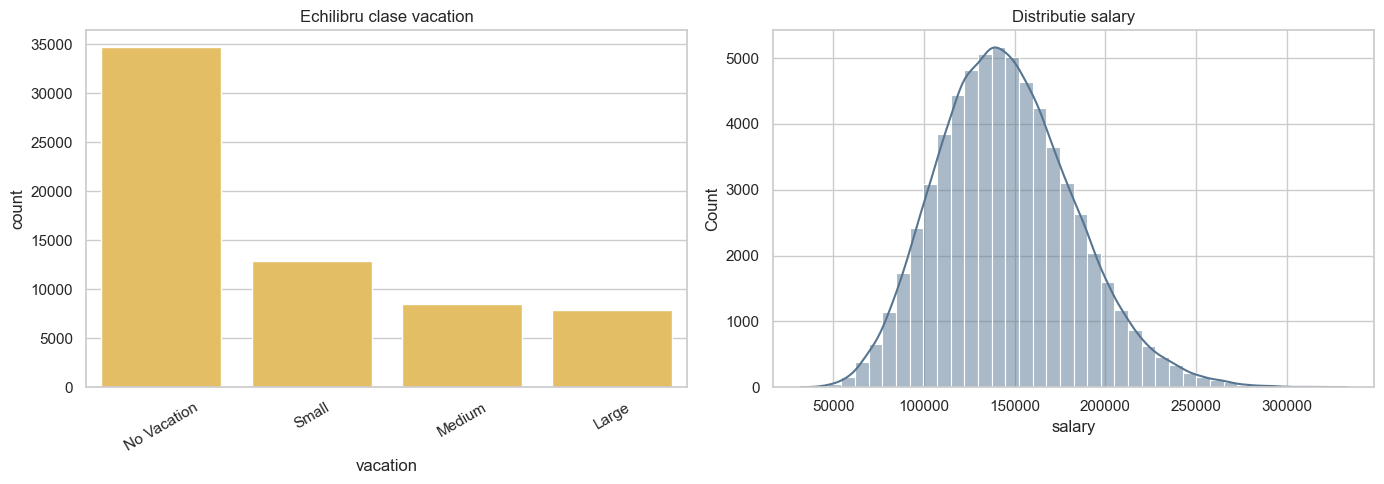

In [7]:
class_balance = pd.concat([
    train_raw[CLASSIFICATION_TARGET].value_counts().rename("count"),
    (train_raw[CLASSIFICATION_TARGET].value_counts(normalize=True) * 100).round(2).rename("percent"),
], axis=1)
display(class_balance)

display(train_raw[REGRESSION_TARGET].describe().to_frame("salary").round(2))

if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(x=train_raw[CLASSIFICATION_TARGET], order=train_raw[CLASSIFICATION_TARGET].value_counts().index, ax=axes[0], color="#f9c74f")
    axes[0].set_title("Echilibru clase vacation")
    axes[0].tick_params(axis="x", rotation=30)

    sns.histplot(train_raw[REGRESSION_TARGET], bins=40, kde=True, ax=axes[1], color="#577590")
    axes[1].set_title("Distributie salary")
    plt.tight_layout()
    plt.show()


# PARTEA B - REGRESIE

De aici incepe lucrul strict pentru regresie. Tinta este `salary`.


## B1. EDA specific pentru regresie

Pentru regresie ne intereseaza in mod special cum variaza `salary` in functie de features:

- corelatii numerice cu `salary`;
- diferente de salariu pe categorii;
- cateva scatter/box plots relevante, nu foarte multe, ca sa respectam recomandarea din PDF.


In [8]:
NUMERIC_COLS_WITH_TARGET = NUMERIC_FEATURES_EDA + [REGRESSION_TARGET]
regression_corr = train_raw[NUMERIC_COLS_WITH_TARGET].corr(numeric_only=True)

print("Corelatie numerice cu salary:")
display(regression_corr[REGRESSION_TARGET].sort_values(ascending=False).round(3))

for col in ["job_title", "education_level", "company_size", "location", "remote_work", "skill_bracket"]:
    grouped = train_raw.groupby(col, dropna=False)[REGRESSION_TARGET].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False).round(2)
    print(f"\nSalary by {col}")
    display(grouped)


Corelatie numerice cu salary:


salary               1.000
experience_years     0.437
total_days_worked    0.437
certifications       0.077
skills_count         0.065
aggregated_score    -0.004
Name: salary, dtype: float64


Salary by job_title


,count,mean,median,std
job_title,,,,
AI Engineer,5410,173162.56,171337.5,38102.99
Machine Learning Engineer,5337,163118.60,160990.0,36874.80
Product Manager,5302,157107.45,155277.5,35567.85
Cloud Engineer,5300,152619.18,150332.0,35386.68
DevOps Engineer,5344,150013.86,148571.0,34529.76
Cybersecurity Analyst,5356,147907.72,145822.5,34245.70
Data Scientist,5383,147289.90,145268.0,34156.61
Software Engineer,5272,141563.93,138737.5,33902.85
Backend Developer,5389,139574.41,137083.0,33080.63



Salary by education_level


...

,count,mean,median,std
location,,,,
USA,6352,181341.00,178628.0,37782.33
Canada,6469,167938.89,166020.0,35087.79
UK,6365,160347.37,158671.0,33426.84
Germany,6325,153640.37,151718.0,31782.86
Remote,6328,139429.03,137542.5,28919.00
Sweden,6570,139359.67,138062.0,28993.86
Singapore,6438,139058.85,137503.0,29014.11
Netherlands,6376,138904.57,136798.5,29313.18
Australia,6434,138865.53,137025.5,29264.78



Salary by remote_work


,count,mean,median,std
remote_work,,,,
Yes,14838,149609.81,147698.5,37476.23
NaN,19153,145131.00,142754.0,37411.27
Hybrid,15054,144482.91,141962.0,37218.57
No,14955,143704.32,141238.0,37148.23



Salary by skill_bracket


,count,mean,median,std
skill_bracket,,,,
high,21277,151338.83,149227.0,37797.32
mid,21253,145485.08,142931.0,37225.30
low,21470,140275.62,137846.0,36301.60


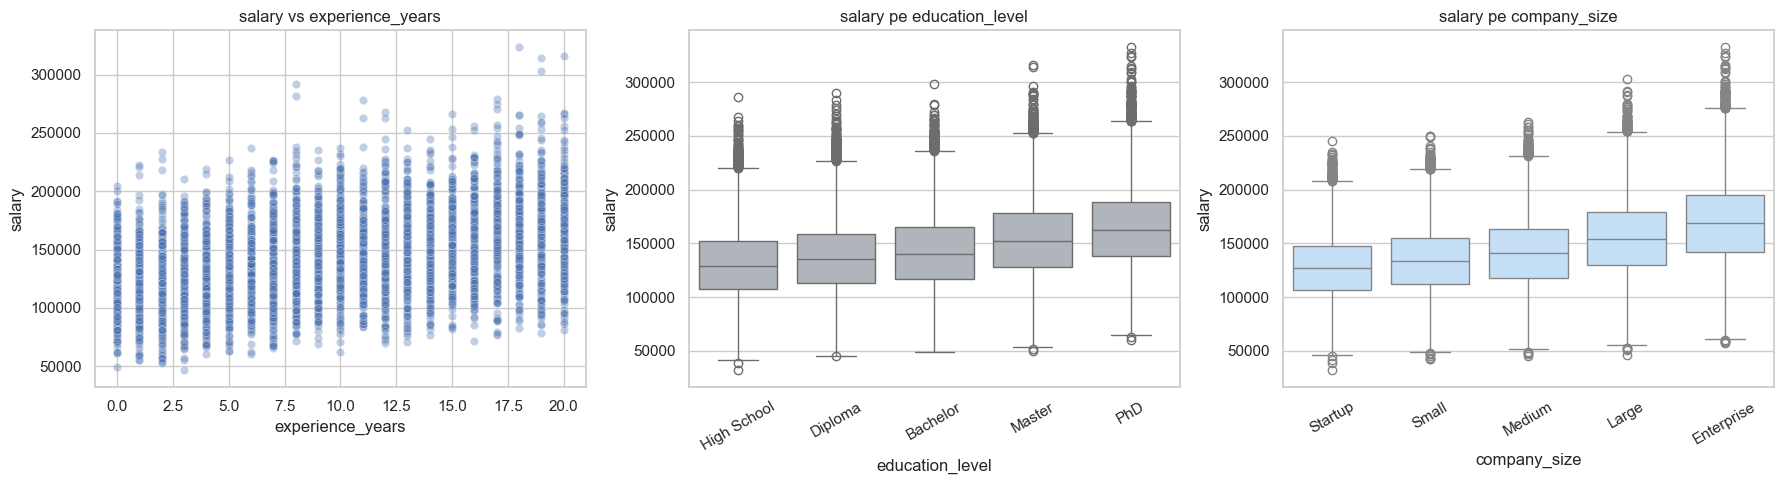

In [9]:
if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.scatterplot(data=train_raw.sample(min(5000, len(train_raw)), random_state=RANDOM_STATE), x="experience_years", y=REGRESSION_TARGET, alpha=0.35, ax=axes[0])
    axes[0].set_title("salary vs experience_years")

    sns.boxplot(data=train_raw, x="education_level", y=REGRESSION_TARGET, order=["High School", "Diploma", "Bachelor", "Master", "PhD"], ax=axes[1], color="#adb5bd")
    axes[1].set_title("salary pe education_level")
    axes[1].tick_params(axis="x", rotation=30)

    sns.boxplot(data=train_raw, x="company_size", y=REGRESSION_TARGET, order=["Startup", "Small", "Medium", "Large", "Enterprise"], ax=axes[2], color="#bde0fe")
    axes[2].set_title("salary pe company_size")
    axes[2].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


## B2. Preprocesare pentru regresie

Preprocesarea este impartita pe niveluri:

**B2.1 Baza pentru regresie**, comuna modelelor de regresie:

- scoatem `salary`, pentru ca este tinta;
- scoatem `vacation`, pentru ca este tinta taskului de clasificare si ar produce leakage;
- scoatem `total_days_worked`, fiind aproape identic cu `experience_years`;
- tratam outlierii din `aggregated_score` prin IQR clipping, cu limite calculate doar pe train;
- adaugam features simple derivate, apoi verificam daca ajuta prin metrici.

**B2.2 Preprocesare specifica familiei de model**, facuta in Pipeline:

- modele liniare: folosesc OneHot pentru toate categoricele, inclusiv `education_level`, `company_size`, `skill_bracket`;
- modele pe arbori/boosting: folosesc variantele ordinale `_ord` pentru `education_level`, `company_size`, `skill_bracket`, iar OneHot ramane doar pentru categorice nominale;
- modelele liniare primesc `StandardScaler`;
- arborii/boosting-ul nu primesc scaler.

Motiv: modelele liniare au nevoie de libertatea OneHot pentru fiecare nivel al unei categorii. Arborii pot folosi eficient o scara ordinala si nu au nevoie sa creeze coloane suplimentare pentru niveluri ordonate.


In [10]:
# Coloane excluse din regresie.
EXCLUDED_FROM_REGRESSION = [REGRESSION_TARGET, CLASSIFICATION_TARGET, "total_days_worked"]
BASE_FEATURES = [c for c in train_raw.columns if c not in EXCLUDED_FROM_REGRESSION]

print("Features folosite in regresie:")
print(BASE_FEATURES)
print("Features excluse:")
print(EXCLUDED_FROM_REGRESSION)

AGG_SCORE_LOWER, AGG_SCORE_UPPER = iqr_bounds(train_raw["aggregated_score"])
outlier_mask = (train_raw["aggregated_score"] < AGG_SCORE_LOWER) | (train_raw["aggregated_score"] > AGG_SCORE_UPPER)
print("aggregated_score IQR bounds:", AGG_SCORE_LOWER, AGG_SCORE_UPPER)
print("Numar outlieri aggregated_score in train:", int(outlier_mask.sum()))


Features folosite in regresie:
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'aggregated_score', 'skill_bracket']
Features excluse:
['salary', 'vacation', 'total_days_worked']
aggregated_score IQR bounds: -2.7018013625585664 2.7063182160590395
Numar outlieri aggregated_score in train: 437


In [11]:

EDUCATION_ORDER = {"High School": 0, "Diploma": 1, "Bachelor": 2, "Master": 3, "PhD": 4}
COMPANY_SIZE_ORDER = {"Startup": 0, "Small": 1, "Medium": 2, "Large": 3, "Enterprise": 4}
SKILL_BRACKET_ORDER = {"low": 0, "mid": 1, "high": 2}

ORDINAL_SOURCE_COLS = ["education_level", "company_size", "skill_bracket"]
ORDINAL_DERIVED_COLS = ["education_level_ord", "company_size_ord", "skill_bracket_ord"]


def add_regression_base_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Tratam outlierii din aggregated_score prin clipping cu limite calculate pe train.
    # Pastram semnul original al scorului; nu mai adaugam abs/sq, ca sa nu pierdem directia negativ/pozitiv.
    if "aggregated_score" in out.columns:
        out["aggregated_score"] = out["aggregated_score"].clip(AGG_SCORE_LOWER, AGG_SCORE_UPPER)

    # Lipsa din remote_work poate fi informatie, deci pastram indicator separat.
    if "remote_work" in out.columns:
        out["remote_work_missing"] = out["remote_work"].isna().astype("int8")

    # Codari ordinale pentru modelele pe arbori/boosting.
    # Pastram si textul original, pentru ca modelele liniare il vor folosi prin OneHot.
    if "education_level" in out.columns:
        out["education_level_ord"] = out["education_level"].map(EDUCATION_ORDER).astype(float)
    if "company_size" in out.columns:
        out["company_size_ord"] = out["company_size"].map(COMPANY_SIZE_ORDER).astype(float)
    if "skill_bracket" in out.columns:
        out["skill_bracket_ord"] = out["skill_bracket"].map(SKILL_BRACKET_ORDER).astype(float)

    # Interactiuni simple pentru experienta + competente.
    if {"experience_years", "skills_count"}.issubset(out.columns):
        years = out["experience_years"].replace(0, np.nan)
        out["skills_per_year"] = (out["skills_count"] / years).replace([np.inf, -np.inf], np.nan).fillna(out["skills_count"])
        out["experience_x_skills"] = out["experience_years"] * out["skills_count"]

    if {"experience_years", "certifications"}.issubset(out.columns):
        years = out["experience_years"].replace(0, np.nan)
        out["certifications_per_year"] = (out["certifications"] / years).replace([np.inf, -np.inf], np.nan).fillna(out["certifications"])

    return out

X_train_base = add_regression_base_features(train_raw[BASE_FEATURES])
y_train = train_raw[REGRESSION_TARGET]
X_test_base = add_regression_base_features(test_raw[BASE_FEATURES])
y_test = test_raw[REGRESSION_TARGET]

CAT_COLS = X_train_base.select_dtypes(include=["object", "category"]).columns.tolist()
NUM_COLS = [c for c in X_train_base.columns if c not in CAT_COLS]

# Modelele liniare folosesc OneHot pe coloanele ordinale originale, deci excludem variantele _ord ca sa evitam dublarea.
LINEAR_NUM_COLS = [c for c in NUM_COLS if c not in ORDINAL_DERIVED_COLS]
LINEAR_CAT_COLS = CAT_COLS

# Modelele pe arbori/boosting folosesc variantele _ord si nu mai fac OneHot pe sursele ordinale.
TREE_NUM_COLS = NUM_COLS
TREE_CAT_COLS = [c for c in CAT_COLS if c not in ORDINAL_SOURCE_COLS]

print("X_train:", X_train_base.shape, "X_test:", X_test_base.shape)
print("Linear numerice:", LINEAR_NUM_COLS)
print("Linear categorice:", LINEAR_CAT_COLS)
print("Tree numerice:", TREE_NUM_COLS)
print("Tree categorice:", TREE_CAT_COLS)


X_train: (64000, 18) X_test: (16000, 18)
Linear numerice: ['experience_years', 'skills_count', 'certifications', 'aggregated_score', 'remote_work_missing', 'skills_per_year', 'experience_x_skills', 'certifications_per_year']
Linear categorice: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'skill_bracket']
Tree numerice: ['experience_years', 'skills_count', 'certifications', 'aggregated_score', 'remote_work_missing', 'education_level_ord', 'company_size_ord', 'skill_bracket_ord', 'skills_per_year', 'experience_x_skills', 'certifications_per_year']
Tree categorice: ['job_title', 'industry', 'location', 'remote_work']


/var/folders/71/k6vnwdys64j39h1cb7d519yw0000gn/T/ipykernel_10077/1504462454.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CAT_COLS = X_train_base.select_dtypes(include=["object", "category"]).columns.tolist()


# B3. Modele de regresie si metrici

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_dense_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_linear_preprocessor():
    """Pentru modele liniare: imputare + OneHot + StandardScaler."""
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder()),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, LINEAR_NUM_COLS),
        ("cat", categorical_pipeline, LINEAR_CAT_COLS),
    ])


def make_tree_preprocessor():
    """Pentru arbori: imputare + OneHot, fara scaler."""
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder()),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, TREE_NUM_COLS),
        ("cat", categorical_pipeline, TREE_CAT_COLS),
    ])


def make_dense_tree_preprocessor():
    """Pentru HistGradientBoosting: imputare + OneHot dens, fara scaler."""
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_dense_one_hot_encoder()),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, TREE_NUM_COLS),
        ("cat", categorical_pipeline, TREE_CAT_COLS),
    ], sparse_threshold=0.0)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_model(name, model, preprocessing_note, hyperparams_note):
    model.fit(X_train_base, y_train)
    train_pred = model.predict(X_train_base)
    test_pred = model.predict(X_test_base)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    row = {
        "model": name,
        "preprocessing": preprocessing_note,
        "hyperparams": hyperparams_note,
        "train_MSE": train_metrics["MSE"],
        "test_MSE": test_metrics["MSE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_MAE": test_metrics["MAE"],
        "test_R2": test_metrics["R2"],
    }
    return row, test_pred, model


## Modelul Baseline - Cerinte minime

- baseline minim cu `LinearRegression`;
- minim un experiment in care adaugam si variem regularizarea;
- tabel comparativ cu metrici de regresie;
- comentarii despre cel mai bun model.

Kaggle evalueaza regresia cu **MSE**, deci alegem modelul dupa `test_MSE`. Raportam si `RMSE`, `MAE`, `R2` pentru interpretare.

In [13]:
# Baseline minim cerut in PDF: LinearRegression.
linear_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", LinearRegression()),
])

linear_metrics, linear_pred, fitted_linear_model = evaluate_model(
    name="LinearRegression_baseline",
    model=linear_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="fara regularizare",
)

display(pd.DataFrame([linear_metrics]))


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231


## B3.1. Experimente cu regularizare - cerinta minima PDF

Dupa baseline-ul `LinearRegression`, PDF-ul cere minim un experiment in care adaugam si variem regularizarea. Aici testam `Ridge`, adica regresie liniara cu penalizare L2 pe coeficienti.

Scop: vedem daca regularizarea reduce overfitting-ul fata de baseline. Pastram baseline-ul ca reper principal.


In [14]:

# Varianta cu regularizare Ridge, testam doua valori diferite pentru alpha, asa cum se cere in PDF.
# Am ales 1.0 si 10.0 ca valori comune de testat pentru Ridge.
ridge_1_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", Ridge(alpha=1.0)),
])
ridge_10_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", Ridge(alpha=10.0)),
])

ridge_1_metrics, ridge_1_pred, fitted_ridge_1_model = evaluate_model(
    name="Ridge_alpha_1",
    model=ridge_1_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="alpha=1.0",
)
ridge_10_metrics, ridge_10_pred, fitted_ridge_10_model = evaluate_model(
    name="Ridge_alpha_10",
    model=ridge_10_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="alpha=10.0",
)

all_results = [linear_metrics, ridge_1_metrics, ridge_10_metrics]
all_predictions = {
    "LinearRegression_baseline": linear_pred,
    "Ridge_alpha_1": ridge_1_pred,
    "Ridge_alpha_10": ridge_10_pred,
}
all_fitted_models = {
    "LinearRegression_baseline": fitted_linear_model,
    "Ridge_alpha_1": fitted_ridge_1_model,
    "Ridge_alpha_10": fitted_ridge_10_model,
}

metrics_df = pd.DataFrame(all_results).sort_values("test_MSE")
display(metrics_df)


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231
1,Ridge_alpha_1,imputare + OneHot + StandardScaler,alpha=1.0,5.560510e+07,5.493713e+07,7411.958401,5731.141391,0.960230
2,Ridge_alpha_10,imputare + OneHot + StandardScaler,alpha=10.0,5.560724e+07,5.494210e+07,7412.293624,5731.146498,0.960227


### B3.2. Lasso - regularizare L1 si selectie de features

`Lasso` este tot regresie liniara, dar cu penalizare L1. Diferenta fata de Ridge este ca Lasso poate impinge unii coeficienti exact la `0`.

De ce ne intereseaza aici: daca unele features inventate prin feature engineering sunt inutile, Lasso poate sa le ignore automat. Testam mai multe valori de `alpha` si comparam cu baseline-ul.


In [15]:
lasso_experiments = []
for alpha in [0.1, 1.0, 10.0]:
    lasso_model = Pipeline([
        ("preprocess", make_linear_preprocessor()),
        ("model", Lasso(alpha=alpha, max_iter=5000, random_state=RANDOM_STATE)),
    ])
    lasso_metrics, lasso_pred, fitted_lasso_model = evaluate_model(
        name=f"Lasso_alpha_{alpha}",
        model=lasso_model,
        preprocessing_note="imputare + OneHot + StandardScaler",
        hyperparams_note=f"alpha={alpha}, penalty=L1",
    )
    lasso_experiments.append(lasso_metrics)
    all_results.append(lasso_metrics)
    all_predictions[lasso_metrics["model"]] = lasso_pred
    all_fitted_models[lasso_metrics["model"]] = fitted_lasso_model

display(pd.DataFrame(lasso_experiments).sort_values("test_MSE"))




/Users/horicuz/Downloads/Tema1-CC 2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.851e+11, tolerance: 8.945e+09
  model = cd_fast.sparse_enet_coordinate_descent(


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
1,Lasso_alpha_1.0,imputare + OneHot + StandardScaler,"alpha=1.0, penalty=L1",5.560554e+07,5.493505e+07,7411.817998,5731.038661,0.960232
0,Lasso_alpha_0.1,imputare + OneHot + StandardScaler,"alpha=0.1, penalty=L1",5.560506e+07,5.493615e+07,7411.892606,5731.105255,0.960231
2,Lasso_alpha_10.0,imputare + OneHot + StandardScaler,"alpha=10.0, penalty=L1",5.563711e+07,5.496589e+07,7413.898515,5732.703721,0.960210


## B4. PERFECTIONARE - Kaggle

Pana aici am bifat cerinta minima: `LinearRegression` + regularizare `Ridge`/`Lasso`. De aici incercam modele mai puternice, dar pastram comparatia cu regresia liniara.

Pentru date tabelare, cele mai bune modele sunt de obicei cele de tip ensemble/boosting pe arbori. Am pastrat mai jos istoricul modelelor exploratorii, dar in etapa curenta nu mai rulam toate modelele exploratorii; ne concentram pe CatBoost + Target Encoding si comparatiile cerute.

Modelele exploratorii vechi pot fi reactivate cu `RUN_LEGACY_REGRESSION_MODELS = True`, dar tabelul final ramane concentrat pe: LinearRegression, Lasso, CatBoost nativ, CatBoost cu Target Encoding, log-target si Null Importance.


### B4.1. DecisionTreeRegressor - reper neliniar simplu

Un singur arbore imparte datele prin reguli de forma `feature <= prag`. Nu are nevoie de standardizare. Il folosim ca sa vedem daca o neliniaritate simpla bate modelul liniar.


In [16]:
if RUN_LEGACY_REGRESSION_MODELS:
    tree_model = Pipeline([
        ("preprocess", make_tree_preprocessor()),
        ("model", DecisionTreeRegressor(max_depth=30, min_samples_leaf=5, min_samples_split=30, max_features=None, random_state=RANDOM_STATE)),
    ])
    tree_metrics, tree_pred, fitted_tree_model = evaluate_model(
        name="DecisionTree_depth30_leaf5_split30_featNone",
        model=tree_model,
        preprocessing_note="imputare + OneHot, fara scaler",
        hyperparams_note="max_depth=30, min_samples_leaf=5, min_samples_split=30, max_features=None",
    )

    all_results.append(tree_metrics)
    all_predictions["DecisionTree_depth30_leaf5_split30_featNone"] = tree_pred
    all_fitted_models["DecisionTree_depth30_leaf5_split30_featNone"] = fitted_tree_model
    display(pd.DataFrame([tree_metrics]))
else:
    print("Experiment vechi sarit: DecisionTreeRegressor legacy.")


Experiment vechi sarit: DecisionTreeRegressor legacy.


### B4.2. RandomForestRegressor - ensemble stabil de arbori

Random Forest antreneaza mai multi arbori pe subseturi diferite ale datelor si mediaza predictiile. De obicei reduce varianta fata de un singur arbore si este un baseline puternic pentru tabular.


In [17]:
if RUN_LEGACY_REGRESSION_MODELS:
    rf_model = Pipeline([
        ("preprocess", make_tree_preprocessor()),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=18,
            min_samples_leaf=5,
            max_features=0.8,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ])

    rf_metrics, rf_pred, fitted_rf_model = evaluate_model(
        name="RandomForestRegressor_v1",
        model=rf_model,
        preprocessing_note="ordinal pentru categorice ordonate + OneHot nominal, fara scaler",
        hyperparams_note="n_estimators=100, max_depth=18, min_samples_leaf=5, max_features=0.8",
    )

    all_results.append(rf_metrics)
    all_predictions["RandomForestRegressor_v1"] = rf_pred
    all_fitted_models["RandomForestRegressor_v1"] = fitted_rf_model
    display(pd.DataFrame([rf_metrics]))
else:
    print("Experiment vechi sarit: RandomForestRegressor legacy.")


Experiment vechi sarit: RandomForestRegressor legacy.


### B4.3. ExtraTreesRegressor - ensemble mai randomizat

ExtraTrees seamana cu Random Forest, dar introduce mai multa randomizare in splituri. Uneori generalizeaza mai bine si ruleaza competitiv pe date tabelare.


In [18]:
if RUN_LEGACY_REGRESSION_MODELS:
    et_model = Pipeline([
        ("preprocess", make_tree_preprocessor()),
        ("model", ExtraTreesRegressor(
            n_estimators=800,
            max_depth=60,
            min_samples_leaf=3,
            max_features=0.9,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ])

    et_metrics, et_pred, fitted_et_model = evaluate_model(
        name="ExtraTreesRegressor_v1",
        model=et_model,
        preprocessing_note="ordinal pentru categorice ordonate + OneHot nominal, fara scaler",
        hyperparams_note="n_estimators=800, max_depth=60, min_samples_leaf=3, max_features=0.9",
    )

    all_results.append(et_metrics)
    all_predictions["ExtraTreesRegressor_v1"] = et_pred
    all_fitted_models["ExtraTreesRegressor_v1"] = fitted_et_model
    display(pd.DataFrame([et_metrics]))
else:
    print("Experiment vechi sarit: ExtraTreesRegressor legacy.")


Experiment vechi sarit: ExtraTreesRegressor legacy.


### B4.4. HistGradientBoostingRegressor - prima incercare serioasa de boosting

Boosting-ul construieste arbori secvential. Fiecare arbore nou incearca sa corecteze erorile ramase de modelul anterior. Este un model potrivit pentru tabular si poate prinde interactiuni intre features.


In [19]:
if RUN_LEGACY_REGRESSION_MODELS:
    hgb_model = Pipeline([
        ("preprocess", make_dense_tree_preprocessor()),
        ("model", HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.1,
            max_iter=220,
            max_leaf_nodes=31,
            l2_regularization=0.0,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=RANDOM_STATE,
        )),
    ])

    hgb_metrics, hgb_pred, fitted_hgb_model = evaluate_model(
        name="HistGradientBoosting_v1",
        model=hgb_model,
        preprocessing_note="imputare + OneHot dens, fara scaler",
        hyperparams_note="learning_rate=0.1, max_iter=220, max_leaf_nodes=31, early_stopping=True",
    )

    all_results.append(hgb_metrics)
    all_predictions["HistGradientBoosting_v1"] = hgb_pred
    all_fitted_models["HistGradientBoosting_v1"] = fitted_hgb_model
    display(pd.DataFrame([hgb_metrics]))
else:
    print("Experiment vechi sarit: HistGradientBoostingRegressor legacy.")


Experiment vechi sarit: HistGradientBoostingRegressor legacy.


### B4.5. XGBRegressor - model orientat spre leaderboard

XGBoost este o implementare foarte puternica de gradient boosting. Il testam fiindca este des folosit pe Kaggle pentru date tabelare. Folosim un set conservator de hiperparametri, ca prima incercare, nu tuning final.


In [20]:
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBOOST_AVAILABLE = False
    print("XGBoost nu poate fi folosit in mediul curent; sarim peste XGBRegressor.")
    print("Motiv:", type(exc).__name__, str(exc).split("\n")[0])

if XGBOOST_AVAILABLE and RUN_LEGACY_REGRESSION_MODELS:
    try:
        xgb_model = Pipeline([
            ("preprocess", make_tree_preprocessor()),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=3,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                n_jobs=1,
            )),
        ])

        xgb_metrics, xgb_pred, fitted_xgb_model = evaluate_model(
            name="XGBRegressor_v1",
            model=xgb_model,
            preprocessing_note="imputare + OneHot, fara scaler",
            hyperparams_note="n_estimators=500, learning_rate=0.05, max_depth=4, min_child_weight=3",
        )

        all_results.append(xgb_metrics)
        all_predictions["XGBRegressor_v1"] = xgb_pred
        all_fitted_models["XGBRegressor_v1"] = fitted_xgb_model
        display(pd.DataFrame([xgb_metrics]))
    except Exception as exc:
        print("XGBRegressor a esuat la antrenare; pastram restul experimentelor.")
        print("Motiv:", type(exc).__name__, str(exc).split("\n")[0])
elif XGBOOST_AVAILABLE:
    print("Experiment vechi sarit: XGBRegressor_v1 legacy.")


Experiment vechi sarit: XGBRegressor_v1 legacy.


### B4.6. LightGBM si CatBoost - boosting extern

Aceste modele sunt tot pentru **regresie**, nu doar pentru clasificare. Le rulam doar daca bibliotecile sunt disponibile in mediu. Daca lipseste o dependinta nativa, notebook-ul nu se opreste: afiseaza motivul si trece mai departe.

In [21]:
import importlib.util

external_availability = []

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    LIGHTGBM_AVAILABLE = False
    external_availability.append({
        "model": "LightGBM",
        "package": "lightgbm",
        "available": False,
        "note": f"{type(exc).__name__}: {str(exc).split(chr(10))[0]}",
    })

if LIGHTGBM_AVAILABLE and RUN_LEGACY_REGRESSION_MODELS:
    external_availability.append({
        "model": "LightGBM",
        "package": "lightgbm",
        "available": True,
        "note": "ruleaza ca LGBMRegressor",
    })
    try:
        lgbm_model = Pipeline([
            ("preprocess", make_tree_preprocessor()),
            ("model", LGBMRegressor(
                objective="regression",
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=20,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1,
            )),
        ])

        lgbm_metrics, lgbm_pred, fitted_lgbm_model = evaluate_model(
            name="LGBMRegressor_v1",
            model=lgbm_model,
            preprocessing_note="ordinal pentru categorice ordonate + OneHot nominal, fara scaler",
            hyperparams_note="n_estimators=500, learning_rate=0.05, num_leaves=31, reg_lambda=1.0",
        )

        all_results.append(lgbm_metrics)
        all_predictions["LGBMRegressor_v1"] = lgbm_pred
        all_fitted_models["LGBMRegressor_v1"] = fitted_lgbm_model
        display(pd.DataFrame([lgbm_metrics]))
    except Exception as exc:
        print("LGBMRegressor a esuat la antrenare; pastram restul experimentelor.")
        print("Motiv:", type(exc).__name__, str(exc).split("\n")[0])

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception as exc:
    CATBOOST_AVAILABLE = False
    external_availability.append({
        "model": "CatBoost",
        "package": "catboost",
        "available": False,
        "note": f"{type(exc).__name__}: {str(exc).split(chr(10))[0]}",
    })

if CATBOOST_AVAILABLE and RUN_LEGACY_REGRESSION_MODELS:
    external_availability.append({
        "model": "CatBoost",
        "package": "catboost",
        "available": True,
        "note": "ruleaza ca CatBoostRegressor",
    })
    try:
        cat_model = Pipeline([
            ("preprocess", make_tree_preprocessor()),
            ("model", CatBoostRegressor(
                loss_function="RMSE",
                iterations=500,
                learning_rate=0.05,
                depth=6,
                l2_leaf_reg=3.0,
                random_seed=RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
                thread_count=-1,
            )),
        ])

        cat_metrics, cat_pred, fitted_cat_model = evaluate_model(
            name="CatBoostRegressor_v1",
            model=cat_model,
            preprocessing_note="ordinal pentru categorice ordonate + OneHot nominal, fara scaler",
            hyperparams_note="iterations=500, learning_rate=0.05, depth=6, l2_leaf_reg=3.0",
        )

        all_results.append(cat_metrics)
        all_predictions["CatBoostRegressor_v1"] = cat_pred
        all_fitted_models["CatBoostRegressor_v1"] = fitted_cat_model
        display(pd.DataFrame([cat_metrics]))
    except Exception as exc:
        print("CatBoostRegressor a esuat la antrenare; pastram restul experimentelor.")
        print("Motiv:", type(exc).__name__, str(exc).split("\n")[0])

if not RUN_LEGACY_REGRESSION_MODELS:
    print("Experimente vechi sarite: LGBMRegressor_v1 legacy si CatBoostRegressor_v1 legacy.")

display(pd.DataFrame(external_availability))


Experimente vechi sarite: LGBMRegressor_v1 legacy si CatBoostRegressor_v1 legacy.


""


### B4.7. Adversarial Validation - verificam daca testul privat seamana cu datele locale

Aceasta nu este antrenare pentru `salary`, ci un diagnostic de competitie. Comparam randurile locale cu randurile din `CC_private_test.csv`. Daca un clasificator poate ghici usor ce rand vine din testul privat, inseamna ca distributiile difera si trebuie sa fim atenti la feature-urile care produc diferenta.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

if private_test_raw is None:
    adversarial_summary = pd.DataFrame([{"status": "skipped", "reason": "Nu exista CC_private_test.csv"}])
    adversarial_importance_df = pd.DataFrame()
    display(adversarial_summary)
else:
    adv_features = [c for c in BASE_FEATURES if c in private_test_raw.columns]

    adv_local_raw = pd.concat([
        train_raw[adv_features],
        test_raw[adv_features],
    ], ignore_index=True)
    adv_private_raw = private_test_raw[adv_features].copy()

    X_adv_raw = pd.concat([adv_local_raw, adv_private_raw], ignore_index=True)
    y_adv = pd.Series(
        [0] * len(adv_local_raw) + [1] * len(adv_private_raw),
        name="is_private_test",
    )
    X_adv_base = add_regression_base_features(X_adv_raw)

    X_adv_train, X_adv_valid, y_adv_train, y_adv_valid = train_test_split(
        X_adv_base,
        y_adv,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_adv,
    )

    adversarial_model = Pipeline([
        ("preprocess", make_tree_preprocessor()),
        ("model", RandomForestClassifier(
            n_estimators=160,
            max_depth=12,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    adversarial_model.fit(X_adv_train, y_adv_train)
    adv_prob = adversarial_model.predict_proba(X_adv_valid)[:, 1]
    adversarial_auc = roc_auc_score(y_adv_valid, adv_prob)

    if adversarial_auc < 0.55:
        drift_note = "Train/local test si testul privat par foarte asemanatoare."
    elif adversarial_auc < 0.70:
        drift_note = "Exista diferente moderate; verificam feature-urile de mai jos."
    else:
        drift_note = "Exista drift puternic intre datele locale si testul privat."

    adversarial_summary = pd.DataFrame([{
        "AUC_is_private_test": adversarial_auc,
        "interpretare": drift_note,
        "local_rows": len(adv_local_raw),
        "private_rows": len(adv_private_raw),
    }])
    display(adversarial_summary)

    adv_sample_size = min(5000, len(X_adv_valid))
    X_adv_sample = X_adv_valid.sample(n=adv_sample_size, random_state=RANDOM_STATE)
    y_adv_sample = y_adv_valid.loc[X_adv_sample.index]

    adv_perm = permutation_importance(
        adversarial_model,
        X_adv_sample,
        y_adv_sample,
        scoring="roc_auc",
        n_repeats=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    adversarial_importance_df = pd.DataFrame({
        "feature": X_adv_sample.columns,
        "importance_mean": adv_perm.importances_mean,
        "importance_std": adv_perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    display(adversarial_importance_df.head(10))


,AUC_is_private_test,interpretare,local_rows,private_rows
0,0.76831,Exista drift puternic intre datele locale si t...,80000,16000


,feature,importance_mean,importance_std
12,education_level_ord,0.019859,0.001402
13,company_size_ord,0.014144,0.001235
2,education_level,0.000000,0.000000
5,company_size,0.000000,0.000000
10,skill_bracket,0.000000,0.000000
11,remote_work_missing,-0.000645,0.000190
1,experience_years,-0.001089,0.001379
14,skill_bracket_ord,-0.001212,0.000620
15,skills_per_year,-0.001516,0.001920
8,certifications,-0.002546,0.001035


### B4.8. Target Encoding cu K-Fold intern - feature engineering pentru modele de leaderboard

Aici incercam o tehnica mai puternica decat OneHot pentru categorice: inlocuim o categorie cu media targetului pentru acea categorie. Ca sa evitam data leakage, transformerul produce encodari out-of-fold pe datele de antrenare: pentru fiecare fold intern, media este calculata doar din celelalte fold-uri.

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold

class KFoldTargetEncodingPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_cols, categorical_cols, n_splits=5, smoothing=30.0, random_state=42):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.random_state = random_state

    def _as_frame(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        return pd.DataFrame(X)

    def _category_series(self, X, col):
        if col in X.columns:
            return X[col].astype("object").where(X[col].notna(), "Missing").astype(str)
        return pd.Series("Missing", index=X.index, dtype="object")

    def _mapping(self, categories, y):
        tmp = pd.DataFrame({"category": categories, "target": np.asarray(y, dtype=float)})
        stats = tmp.groupby("category")["target"].agg(["mean", "count"])
        smooth = (stats["mean"] * stats["count"] + self.global_mean_ * self.smoothing) / (stats["count"] + self.smoothing)
        return smooth

    def _numeric_frame(self, X):
        out = pd.DataFrame(index=X.index)
        for col in self.numeric_cols:
            if col in X.columns:
                values = pd.to_numeric(X[col], errors="coerce")
            else:
                values = pd.Series(np.nan, index=X.index)
            out[col] = values.fillna(self.numeric_medians_.get(col, 0.0))
        return out

    def fit(self, X, y):
        X = self._as_frame(X)
        y = pd.Series(y).reset_index(drop=True)
        X = X.reset_index(drop=True)

        self.global_mean_ = float(y.mean())
        self.numeric_medians_ = {}
        for col in self.numeric_cols:
            if col in X.columns:
                self.numeric_medians_[col] = float(pd.to_numeric(X[col], errors="coerce").median())
            else:
                self.numeric_medians_[col] = 0.0
            if np.isnan(self.numeric_medians_[col]):
                self.numeric_medians_[col] = 0.0

        self.category_maps_ = {}
        for col in self.categorical_cols:
            self.category_maps_[col] = self._mapping(self._category_series(X, col), y)
        return self

    def fit_transform(self, X, y=None, **fit_params):
        if y is None:
            raise ValueError("KFoldTargetEncodingPreprocessor are nevoie de y pentru fit_transform.")

        X = self._as_frame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)
        self.fit(X, y)

        out = self._numeric_frame(X)
        n_splits = min(self.n_splits, len(X))
        inner_cv = KFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)

        for col in self.categorical_cols:
            encoded = pd.Series(self.global_mean_, index=X.index, dtype=float)
            categories = self._category_series(X, col)
            for train_idx, valid_idx in inner_cv.split(X):
                mapping = self._mapping(categories.iloc[train_idx], y.iloc[train_idx])
                encoded.iloc[valid_idx] = categories.iloc[valid_idx].map(mapping).fillna(self.global_mean_).astype(float)
            out[f"{col}_target_mean"] = encoded

        return out.to_numpy(dtype=float)

    def transform(self, X):
        X = self._as_frame(X).reset_index(drop=True)
        out = self._numeric_frame(X)
        for col in self.categorical_cols:
            categories = self._category_series(X, col)
            out[f"{col}_target_mean"] = categories.map(self.category_maps_[col]).fillna(self.global_mean_).astype(float)
        return out.to_numpy(dtype=float)


def make_target_encoding_preprocessor():
    return KFoldTargetEncodingPreprocessor(
        numeric_cols=TREE_NUM_COLS,
        categorical_cols=CAT_COLS,
        n_splits=5,
        smoothing=30.0,
        random_state=RANDOM_STATE,
    )


In [24]:
target_encoding_results = []

if XGBOOST_AVAILABLE and RUN_LEGACY_REGRESSION_MODELS:
    xgb_te_model = Pipeline([
        ("preprocess", make_target_encoding_preprocessor()),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            n_estimators=600,
            learning_rate=0.04,
            max_depth=4,
            min_child_weight=3,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    xgb_te_metrics, xgb_te_pred, fitted_xgb_te_model = evaluate_model(
        name="XGBRegressor_target_encoding_v1",
        model=xgb_te_model,
        preprocessing_note="K-Fold Target Encoding + numerice, fara scaler",
        hyperparams_note="n_estimators=600, learning_rate=0.04, max_depth=4",
    )
    target_encoding_results.append(xgb_te_metrics)
    all_results.append(xgb_te_metrics)
    all_predictions[xgb_te_metrics["model"]] = xgb_te_pred
    all_fitted_models[xgb_te_metrics["model"]] = fitted_xgb_te_model

if LIGHTGBM_AVAILABLE and RUN_LEGACY_REGRESSION_MODELS:
    lgbm_te_model = Pipeline([
        ("preprocess", make_target_encoding_preprocessor()),
        ("model", LGBMRegressor(
            objective="regression",
            n_estimators=600,
            learning_rate=0.04,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )),
    ])
    lgbm_te_metrics, lgbm_te_pred, fitted_lgbm_te_model = evaluate_model(
        name="LGBMRegressor_target_encoding_v1",
        model=lgbm_te_model,
        preprocessing_note="K-Fold Target Encoding + numerice, fara scaler",
        hyperparams_note="n_estimators=600, learning_rate=0.04, num_leaves=31",
    )
    target_encoding_results.append(lgbm_te_metrics)
    all_results.append(lgbm_te_metrics)
    all_predictions[lgbm_te_metrics["model"]] = lgbm_te_pred
    all_fitted_models[lgbm_te_metrics["model"]] = fitted_lgbm_te_model

if not RUN_LEGACY_REGRESSION_MODELS:
    print("Experimente vechi sarite: XGB/LGBM target encoding legacy.")

if CATBOOST_AVAILABLE:
    cat_te_model = Pipeline([
        ("preprocess", make_target_encoding_preprocessor()),
        ("model", CatBoostRegressor(
            loss_function="RMSE",
            iterations=600,
            learning_rate=0.04,
            depth=6,
            l2_leaf_reg=3.0,
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )),
    ])
    cat_te_metrics, cat_te_pred, fitted_cat_te_model = evaluate_model(
        name="CatBoostRegressor_target_encoding_v1",
        model=cat_te_model,
        preprocessing_note="K-Fold Target Encoding + numerice, fara scaler",
        hyperparams_note="iterations=600, learning_rate=0.04, depth=6",
    )
    target_encoding_results.append(cat_te_metrics)
    all_results.append(cat_te_metrics)
    all_predictions[cat_te_metrics["model"]] = cat_te_pred
    all_fitted_models[cat_te_metrics["model"]] = fitted_cat_te_model

display(pd.DataFrame(target_encoding_results).sort_values("test_MSE"))


Experimente vechi sarite: XGB/LGBM target encoding legacy.


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,CatBoostRegressor_target_encoding_v1,"K-Fold Target Encoding + numerice, fara scaler","iterations=600, learning_rate=0.04, depth=6",2.665180e+07,2.758477e+07,5252.12016,4194.322794,0.980031


### B4.9. CatBoost nativ cu categorice text

Acest experiment testeaza CatBoost in modul pentru care a fost construit: ii dam coloanele text direct si ii spunem explicit care sunt `cat_features`. Nu folosim OneHotEncoder, OrdinalEncoder sau TargetEncoder manual pentru acest model.

In [25]:
from sklearn.base import RegressorMixin

CATBOOST_NATIVE_FEATURES = BASE_FEATURES.copy()
CATBOOST_NATIVE_CAT_COLS = train_raw[CATBOOST_NATIVE_FEATURES].select_dtypes(include=["object", "category", "string"]).columns.tolist()
TARGET_ENCODING_FEATURE_NAMES = TREE_NUM_COLS + [f"{col}_target_mean" for col in CAT_COLS]


def make_catboost_native_frame(df: pd.DataFrame) -> pd.DataFrame:
    feature_cols = [c for c in CATBOOST_NATIVE_FEATURES if c in df.columns]
    out = df[feature_cols].copy()
    for col in CATBOOST_NATIVE_CAT_COLS:
        if col in out.columns:
            out[col] = out[col].astype("object").where(out[col].notna(), "Missing").astype(str)
    return out


def adversarial_private_probability(df: pd.DataFrame) -> np.ndarray:
    """Probabilitatea ca un rand local sa semene cu testul privat."""
    if "adversarial_model" not in globals():
        return np.full(len(df), 0.5, dtype=float)
    feature_cols = [c for c in BASE_FEATURES if c in df.columns]
    X_adv_like = add_regression_base_features(df[feature_cols])
    return adversarial_model.predict_proba(X_adv_like)[:, 1]


def adversarial_similarity_weights(
    df: pd.DataFrame,
    strategy: str = "sqrt_odds",
    p_clip=(0.05, 0.95),
    weight_clip=(0.35, 3.0),
) -> np.ndarray:
    """Greutati de domain adaptation. Momentan le pastram doar pentru istoric/experimente viitoare."""
    p = adversarial_private_probability(df)
    p = np.clip(p, p_clip[0], p_clip[1])

    if strategy == "probability":
        weights = p
    elif strategy == "odds":
        weights = p / (1 - p)
    elif strategy == "sqrt_odds":
        weights = np.sqrt(p / (1 - p))
    else:
        raise ValueError(f"Strategie de weights necunoscuta: {strategy}")

    if weight_clip is not None:
        weights = np.clip(weights, weight_clip[0], weight_clip[1])

    weights = weights / np.mean(weights)
    return weights.astype(float)


def select_encoded_columns(X_encoded: np.ndarray, selected_features):
    if selected_features is None:
        return X_encoded
    feature_to_idx = {name: idx for idx, name in enumerate(TARGET_ENCODING_FEATURE_NAMES)}
    selected_idx = [feature_to_idx[name] for name in selected_features if name in feature_to_idx]
    if not selected_idx:
        return X_encoded
    return X_encoded[:, selected_idx]


class CatBoostNativeRegressorEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, iterations=600, learning_rate=0.04, depth=6, l2_leaf_reg=3.0,
                 random_state=42, adversarial_weight_strategy=None):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.random_state = random_state
        self.adversarial_weight_strategy = adversarial_weight_strategy

    def fit(self, X, y):
        X_native = make_catboost_native_frame(X)
        sample_weight = None
        if self.adversarial_weight_strategy is not None:
            sample_weight = adversarial_similarity_weights(X, strategy=self.adversarial_weight_strategy)

        self.model_ = CatBoostRegressor(
            loss_function="RMSE",
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            l2_leaf_reg=self.l2_leaf_reg,
            random_seed=self.random_state,
            cat_features=CATBOOST_NATIVE_CAT_COLS,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )
        self.model_.fit(X_native, y, sample_weight=sample_weight)
        return self

    def predict(self, X):
        X_native = make_catboost_native_frame(X)
        return self.model_.predict(X_native)


class TargetEncodedCatBoostRegressorEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, iterations=600, learning_rate=0.04, depth=6, l2_leaf_reg=3.0,
                 random_state=42, log_target=False, selected_features=None,
                 adversarial_weight_strategy=None):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.random_state = random_state
        self.log_target = log_target
        self.selected_features = selected_features
        self.adversarial_weight_strategy = adversarial_weight_strategy

    def fit(self, X, y):
        self.preprocessor_ = make_target_encoding_preprocessor()
        X_encoded = self.preprocessor_.fit_transform(X, y)
        X_encoded = select_encoded_columns(X_encoded, self.selected_features)

        y_model = np.log1p(y) if self.log_target else y
        sample_weight = None
        if self.adversarial_weight_strategy is not None:
            sample_weight = adversarial_similarity_weights(X, strategy=self.adversarial_weight_strategy)

        self.model_ = CatBoostRegressor(
            loss_function="RMSE",
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            l2_leaf_reg=self.l2_leaf_reg,
            random_seed=self.random_state,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )
        self.model_.fit(X_encoded, y_model, sample_weight=sample_weight)
        return self

    def predict(self, X):
        X_encoded = self.preprocessor_.transform(X)
        X_encoded = select_encoded_columns(X_encoded, self.selected_features)
        pred = self.model_.predict(X_encoded)
        if self.log_target:
            pred = np.expm1(pred)
            pred = np.clip(pred, 0, None)
        return pred


print("CatBoost native features:", CATBOOST_NATIVE_FEATURES)
print("CatBoost native cat_features:", CATBOOST_NATIVE_CAT_COLS)
print("Target encoding feature names:", TARGET_ENCODING_FEATURE_NAMES)


CatBoost native features: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'aggregated_score', 'skill_bracket']
CatBoost native cat_features: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'skill_bracket']
Target encoding feature names: ['experience_years', 'skills_count', 'certifications', 'aggregated_score', 'remote_work_missing', 'education_level_ord', 'company_size_ord', 'skill_bracket_ord', 'skills_per_year', 'experience_x_skills', 'certifications_per_year', 'job_title_target_mean', 'education_level_target_mean', 'industry_target_mean', 'company_size_target_mean', 'location_target_mean', 'remote_work_target_mean', 'skill_bracket_target_mean']


In [26]:
catboost_native_results = []

if CATBOOST_AVAILABLE:
    cat_native_model = CatBoostNativeRegressorEstimator(
        iterations=600,
        learning_rate=0.04,
        depth=6,
        l2_leaf_reg=3.0,
        random_state=RANDOM_STATE,
        adversarial_weight_strategy=None,
    )
    cat_native_metrics, cat_native_pred, fitted_cat_native_model = evaluate_model(
        name="CatBoost_native_categoricals_v1",
        model=cat_native_model,
        preprocessing_note="categorice text native CatBoost, fara OneHot/Ordinal/TargetEncoding manual",
        hyperparams_note="iterations=600, learning_rate=0.04, depth=6, l2_leaf_reg=3.0",
    )
    catboost_native_results.append(cat_native_metrics)
    all_results.append(cat_native_metrics)
    all_predictions[cat_native_metrics["model"]] = cat_native_pred
    all_fitted_models[cat_native_metrics["model"]] = fitted_cat_native_model
else:
    print("CatBoost nu este disponibil, sarim peste experimentul CatBoost nativ.")

display(pd.DataFrame(catboost_native_results).sort_values("test_MSE"))


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,CatBoost_native_categoricals_v1,"categorice text native CatBoost, fara OneHot/O...","iterations=600, learning_rate=0.04, depth=6, l...",2.792887e+07,2.852922e+07,5341.275378,4260.358968,0.979347


### B4.10. Log-transform pe target pentru CatBoost + Target Encoding

Aici testam ipoteza ca `salary` este prea asimetric pentru MSE direct. Modelul este antrenat pe `log1p(salary)`, dar predicțiile sunt transformate inapoi cu `expm1` inainte de calculul MSE.

In [27]:
log_target_results = []

if CATBOOST_AVAILABLE:
    cat_te_log_model = TargetEncodedCatBoostRegressorEstimator(
        iterations=600,
        learning_rate=0.04,
        depth=6,
        l2_leaf_reg=3.0,
        random_state=RANDOM_STATE,
        log_target=True,
        selected_features=None,
        adversarial_weight_strategy=None,
    )
    cat_te_log_metrics, cat_te_log_pred, fitted_cat_te_log_model = evaluate_model(
        name="CatBoost_target_encoding_log_v1",
        model=cat_te_log_model,
        preprocessing_note="K-Fold Target Encoding + log1p(salary), fara weights",
        hyperparams_note="iterations=600, learning_rate=0.04, depth=6, target=log1p(salary)",
    )
    log_target_results.append(cat_te_log_metrics)
    all_results.append(cat_te_log_metrics)
    all_predictions[cat_te_log_metrics["model"]] = cat_te_log_pred
    all_fitted_models[cat_te_log_metrics["model"]] = fitted_cat_te_log_model

display(pd.DataFrame(log_target_results).sort_values("test_MSE"))


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,CatBoost_target_encoding_log_v1,"K-Fold Target Encoding + log1p(salary), fara w...","iterations=600, learning_rate=0.04, depth=6, t...",2.661098e+07,2.748652e+07,5242.758802,4183.398872,0.980102


### B4.12. Optuna Hyperparameter Tuning pentru CatBoost + Target Encoding + log-target

Tuning-ul greu ruleaza separat in `optuna_catboost_log_tuning.py`, ca sa nu relansam 30 de trial-uri de fiecare data cand executam notebook-ul.

Obiectivul Optuna este `cv_MSE_mean`, calculat cu acelasi K-Fold pe `train + test local`, acelasi K-Fold Target Encoding si aceeasi transformare `log1p(salary)` / `expm1(prediction)`.

Rezultatele sunt salvate in:

- `optuna_catboost_log_trials.csv` pentru istoricul trial-urilor;
- `optuna_catboost_log_best.json` pentru parametrii castigatori.


In [30]:
import json
from pathlib import Path

OPTUNA_BEST_PATH = Path("optuna_catboost_log_best.json")
OPTUNA_TRIALS_PATH = Path("optuna_catboost_log_trials.csv")
OPTUNA_BEST_PARAMS = None
optuna_best = None

if OPTUNA_BEST_PATH.exists() and OPTUNA_TRIALS_PATH.exists() and CATBOOST_AVAILABLE:
    optuna_best = json.loads(OPTUNA_BEST_PATH.read_text())
    OPTUNA_BEST_PARAMS = optuna_best["params"]

    optuna_summary_df = pd.DataFrame([{
        "model": optuna_best["model"],
        "n_trials": optuna_best["n_trials"],
        "cv_MSE_mean": optuna_best["cv_MSE_mean"],
        "cv_MSE_std": optuna_best["cv_MSE_std"],
        "iterations": OPTUNA_BEST_PARAMS["iterations"],
        "learning_rate": OPTUNA_BEST_PARAMS["learning_rate"],
        "depth": OPTUNA_BEST_PARAMS["depth"],
        "l2_leaf_reg": OPTUNA_BEST_PARAMS["l2_leaf_reg"],
    }])
    display(optuna_summary_df)

    optuna_trials_df = pd.read_csv(OPTUNA_TRIALS_PATH).sort_values("value")
    display(optuna_trials_df.head(10))

    optuna_model_name = "CatBoost_target_encoding_log_optuna_v1"
    all_results[:] = [row for row in all_results if row.get("model") != optuna_model_name]
    all_predictions.pop(optuna_model_name, None)
    all_fitted_models.pop(optuna_model_name, None)

    cat_te_log_optuna_model = TargetEncodedCatBoostRegressorEstimator(
        iterations=int(OPTUNA_BEST_PARAMS["iterations"]),
        learning_rate=float(OPTUNA_BEST_PARAMS["learning_rate"]),
        depth=int(OPTUNA_BEST_PARAMS["depth"]),
        l2_leaf_reg=float(OPTUNA_BEST_PARAMS["l2_leaf_reg"]),
        random_state=RANDOM_STATE,
        log_target=True,
        selected_features=None,
        adversarial_weight_strategy=None,
    )
    optuna_metrics, optuna_pred, fitted_optuna_model = evaluate_model(
        name=optuna_model_name,
        model=cat_te_log_optuna_model,
        preprocessing_note="K-Fold Target Encoding + log1p(salary) + Optuna tuning, fara weights",
        hyperparams_note=(
            f"iterations={int(OPTUNA_BEST_PARAMS['iterations'])}, "
            f"learning_rate={float(OPTUNA_BEST_PARAMS['learning_rate']):.5f}, "
            f"depth={int(OPTUNA_BEST_PARAMS['depth'])}, "
            f"l2_leaf_reg={float(OPTUNA_BEST_PARAMS['l2_leaf_reg']):.5f}"
        ),
    )
    all_results.append(optuna_metrics)
    all_predictions[optuna_model_name] = optuna_pred
    all_fitted_models[optuna_model_name] = fitted_optuna_model
    display(pd.DataFrame([optuna_metrics]))
else:
    print("Nu exista inca rezultate Optuna salvate. Ruleaza in terminal:")
    print(".venv/bin/python optuna_catboost_log_tuning.py --trials 30 --folds 5")


,model,n_trials,cv_MSE_mean,cv_MSE_std,iterations,learning_rate,depth,l2_leaf_reg
0,CatBoost_target_encoding_log_optuna_v1,30,2.739881e+07,251755.650123,2000,0.01844,5,4.574886


,number,value,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,user_attrs_cv_MSE_std,user_attrs_fold_MSE,state
23,23,2.739881e+07,5,2000,4.574886,0.018440,251755.650123,"[27677338.423254073, 27522184.082430653, 27009...",COMPLETE
20,20,2.741900e+07,5,1998,4.464711,0.019471,269362.575739,"[27753535.170260478, 27554858.05858096, 270085...",COMPLETE
28,28,2.742581e+07,5,1839,3.800241,0.022945,279148.041389,"[27762329.694429126, 27601146.732542183, 27006...",COMPLETE
22,22,2.742922e+07,5,1907,4.719873,0.018863,268789.508389,"[27738721.01683345, 27568011.421404343, 269893...",COMPLETE
21,21,2.743102e+07,5,1918,4.444784,0.018703,286639.887106,"[27744618.074374992, 27595803.44433561, 269862...",COMPLETE
19,19,2.744341e+07,5,1620,9.964153,0.020388,270431.142683,"[27759043.579820383, 27602462.371871848, 27041...",COMPLETE
26,26,2.744757e+07,5,1806,4.805637,0.017695,268207.821321,"[27744125.584518623, 27586815.558410916, 27009...",COMPLETE
4,4,2.744794e+07,6,956,3.621062,0.033478,265813.665537,"[27770209.61804732, 27571820.19654753, 2699249...",COMPLETE
2,2,2.745053e+07,4,1402,9.729189,0.051059,252416.004482,"[27733667.048620157, 27610937.0338499, 2705646...",COMPLETE
29,29,2.746222e+07,4,1677,3.761373,0.022668,234880.486905,"[27756156.67635794, 27600825.66380034, 2711978...",COMPLETE


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,CatBoost_target_encoding_log_optuna_v1,K-Fold Target Encoding + log1p(salary) + Optun...,"iterations=2000, learning_rate=0.01844, depth=...",2.659788e+07,2.742703e+07,5237.082012,4179.790157,0.980145


In [31]:
FINAL_REGRESSION_MODEL_NAMES = [
    "LinearRegression_baseline",
    "Lasso_alpha_1.0",
    "CatBoost_native_categoricals_v1",
    "CatBoostRegressor_target_encoding_v1",
    "CatBoost_target_encoding_log_v1",
    "CatBoost_target_encoding_log_optuna_v1",
    "CatBoost_target_encoding_null_features_v1",
    "CatBoost_target_encoding_log_null_v1",
]

metrics_all_df = pd.DataFrame(all_results).sort_values("test_MSE")
metrics_df = metrics_all_df[metrics_all_df["model"].isin(FINAL_REGRESSION_MODEL_NAMES)].sort_values("test_MSE")

display(metrics_df)

metrics_all_df.to_csv("regression_ablation_log_all.csv", index=False)
metrics_df.to_csv("regression_ablation_log.csv", index=False)
print("Saved regression_ablation_log.csv")
print("Saved regression_ablation_log_all.csv")
print("Best final model dupa test_MSE:", metrics_df.iloc[0]["model"])


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
11,CatBoost_target_encoding_log_optuna_v1,K-Fold Target Encoding + log1p(salary) + Optun...,"iterations=2000, learning_rate=0.01844, depth=...",2.659788e+07,2.742703e+07,5237.082012,4179.790157,0.980145
8,CatBoost_target_encoding_log_v1,"K-Fold Target Encoding + log1p(salary), fara w...","iterations=600, learning_rate=0.04, depth=6, t...",2.661098e+07,2.748652e+07,5242.758802,4183.398872,0.980102
6,CatBoostRegressor_target_encoding_v1,"K-Fold Target Encoding + numerice, fara scaler","iterations=600, learning_rate=0.04, depth=6",2.665180e+07,2.758477e+07,5252.120160,4194.322794,0.980031
7,CatBoost_native_categoricals_v1,"categorice text native CatBoost, fara OneHot/O...","iterations=600, learning_rate=0.04, depth=6, l...",2.792887e+07,2.852922e+07,5341.275378,4260.358968,0.979347
4,Lasso_alpha_1.0,imputare + OneHot + StandardScaler,"alpha=1.0, penalty=L1",5.560554e+07,5.493505e+07,7411.817998,5731.038661,0.960232
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231
10,CatBoost_target_encoding_log_null_v1,K-Fold Target Encoding + log1p(salary) + Null ...,"features=5, iterations=600, learning_rate=0.04...",6.215709e+07,6.188961e+07,7866.994960,6297.236253,0.955197
9,CatBoost_target_encoding_null_features_v1,K-Fold Target Encoding + features selectate pr...,"features=5, iterations=600, learning_rate=0.04...",6.198791e+07,6.194838e+07,7870.729335,6298.676156,0.955155


Saved regression_ablation_log.csv
Saved regression_ablation_log_all.csv
Best final model dupa test_MSE: CatBoost_target_encoding_log_optuna_v1


### B4.13. K-Fold Cross-Validation final pe modele alese

Aici K-Fold este doar etapa de testare mai stabila. Nu mai rulam toate modelele slabe. Pastram baseline-ul obligatoriu, doua regularizari reprezentative si modelele care au sens pentru leaderboard dupa experimentele de perfectionare.

In [32]:
from sklearn.model_selection import KFold

# Set mare pentru validare locala: train + test local, ambele cu salary cunoscut.
regression_cv_raw = pd.concat([train_raw, test_raw], ignore_index=True)
X_cv_base = add_regression_base_features(regression_cv_raw[BASE_FEATURES]).reset_index(drop=True)
y_cv = regression_cv_raw[REGRESSION_TARGET].reset_index(drop=True)

print("Set K-Fold train + test local:", X_cv_base.shape)
print("Target K-Fold:", y_cv.shape)

N_SPLITS = 5
regression_kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def make_regression_cv_model_factories():
    factories = {
        "LinearRegression_baseline": lambda: Pipeline([
            ("preprocess", make_linear_preprocessor()),
            ("model", LinearRegression()),
        ]),
        "Lasso_alpha_1.0": lambda: Pipeline([
            ("preprocess", make_linear_preprocessor()),
            ("model", Lasso(alpha=1.0, max_iter=10000, random_state=RANDOM_STATE)),
        ]),
    }

    if CATBOOST_AVAILABLE:
        factories["CatBoost_native_categoricals_v1"] = lambda: CatBoostNativeRegressorEstimator(
            iterations=600,
            learning_rate=0.04,
            depth=6,
            l2_leaf_reg=3.0,
            random_state=RANDOM_STATE,
            adversarial_weight_strategy=None,
        )
        factories["CatBoostRegressor_target_encoding_v1"] = lambda: TargetEncodedCatBoostRegressorEstimator(
            iterations=600,
            learning_rate=0.04,
            depth=6,
            l2_leaf_reg=3.0,
            random_state=RANDOM_STATE,
            log_target=False,
            selected_features=None,
            adversarial_weight_strategy=None,
        )
        factories["CatBoost_target_encoding_log_v1"] = lambda: TargetEncodedCatBoostRegressorEstimator(
            iterations=600,
            learning_rate=0.04,
            depth=6,
            l2_leaf_reg=3.0,
            random_state=RANDOM_STATE,
            log_target=True,
            selected_features=None,
            adversarial_weight_strategy=None,
        )
        if "OPTUNA_BEST_PARAMS" in globals() and OPTUNA_BEST_PARAMS is not None:
            factories["CatBoost_target_encoding_log_optuna_v1"] = lambda: TargetEncodedCatBoostRegressorEstimator(
                iterations=int(OPTUNA_BEST_PARAMS["iterations"]),
                learning_rate=float(OPTUNA_BEST_PARAMS["learning_rate"]),
                depth=int(OPTUNA_BEST_PARAMS["depth"]),
                l2_leaf_reg=float(OPTUNA_BEST_PARAMS["l2_leaf_reg"]),
                random_state=RANDOM_STATE,
                log_target=True,
                selected_features=None,
                adversarial_weight_strategy=None,
            )
        factories["CatBoost_target_encoding_null_features_v1"] = lambda: TargetEncodedCatBoostRegressorEstimator(
            iterations=600,
            learning_rate=0.04,
            depth=6,
            l2_leaf_reg=3.0,
            random_state=RANDOM_STATE,
            log_target=False,
            selected_features=NULL_SELECTED_FEATURES,
            adversarial_weight_strategy=None,
        )
        factories["CatBoost_target_encoding_log_null_v1"] = lambda: TargetEncodedCatBoostRegressorEstimator(
            iterations=600,
            learning_rate=0.04,
            depth=6,
            l2_leaf_reg=3.0,
            random_state=RANDOM_STATE,
            log_target=True,
            selected_features=NULL_SELECTED_FEATURES,
            adversarial_weight_strategy=None,
        )

    return factories


def evaluate_with_kfold(name, model_factory):
    rows = []
    try:
        for fold_id, (train_idx, valid_idx) in enumerate(regression_kfold.split(X_cv_base), start=1):
            X_fold_train = X_cv_base.iloc[train_idx]
            y_fold_train = y_cv.iloc[train_idx]
            X_fold_valid = X_cv_base.iloc[valid_idx]
            y_fold_valid = y_cv.iloc[valid_idx]

            model = model_factory()
            model.fit(X_fold_train, y_fold_train)

            train_pred = model.predict(X_fold_train)
            valid_pred = model.predict(X_fold_valid)

            train_metrics = regression_metrics(y_fold_train, train_pred)
            valid_metrics = regression_metrics(y_fold_valid, valid_pred)

            rows.append({
                "fold": fold_id,
                "train_MSE": train_metrics["MSE"],
                "cv_MSE": valid_metrics["MSE"],
                "cv_RMSE": valid_metrics["RMSE"],
                "cv_MAE": valid_metrics["MAE"],
                "cv_R2": valid_metrics["R2"],
            })
    except Exception as exc:
        return {
            "model": name,
            "status": "failed",
            "error": f"{type(exc).__name__}: {str(exc).split(chr(10))[0]}",
        }

    fold_df = pd.DataFrame(rows)
    return {
        "model": name,
        "status": "ok",
        "train_MSE_mean": fold_df["train_MSE"].mean(),
        "cv_MSE_mean": fold_df["cv_MSE"].mean(),
        "cv_MSE_std": fold_df["cv_MSE"].std(),
        "cv_RMSE_mean": fold_df["cv_RMSE"].mean(),
        "cv_MAE_mean": fold_df["cv_MAE"].mean(),
        "cv_R2_mean": fold_df["cv_R2"].mean(),
        "selection_metric": "cv_MSE_mean",
    }


cv_model_factories = make_regression_cv_model_factories()
selected_cv_model_names = [name for name in FINAL_REGRESSION_MODEL_NAMES if name in cv_model_factories]

print("Modele testate in K-Fold final:", selected_cv_model_names)

cv_results = []
for model_name in selected_cv_model_names:
    print("K-Fold:", model_name)
    cv_results.append(evaluate_with_kfold(model_name, cv_model_factories[model_name]))

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_MSE_mean", na_position="last")
display(cv_results_df)

cv_results_df.to_csv("regression_kfold_results.csv", index=False)
print("Saved regression_kfold_results.csv")

ok_cv_results_df = cv_results_df.query("status == 'ok'").copy()
if not ok_cv_results_df.empty:
    best_cv_name = ok_cv_results_df.sort_values("cv_MSE_mean").iloc[0]["model"]
    print("Best model dupa K-Fold MSE:", best_cv_name)

    final_cv_model = cv_model_factories[best_cv_name]()
    final_cv_model.fit(X_cv_base, y_cv)
    print("Final CV model fit pe train + test local:", best_cv_name)
else:
    best_cv_name = None
    final_cv_model = None
    print("Nu avem niciun model valid in K-Fold.")


Set K-Fold train + test local: (80000, 18)
Target K-Fold: (80000,)
Modele testate in K-Fold final: ['LinearRegression_baseline', 'Lasso_alpha_1.0', 'CatBoost_native_categoricals_v1', 'CatBoostRegressor_target_encoding_v1', 'CatBoost_target_encoding_log_v1', 'CatBoost_target_encoding_log_optuna_v1', 'CatBoost_target_encoding_null_features_v1', 'CatBoost_target_encoding_log_null_v1']
K-Fold: LinearRegression_baseline


K-Fold: Lasso_alpha_1.0


K-Fold: CatBoost_native_categoricals_v1


K-Fold: CatBoostRegressor_target_encoding_v1


K-Fold: CatBoost_target_encoding_log_v1


...

K-Fold: CatBoost_target_encoding_null_features_v1


K-Fold: CatBoost_target_encoding_log_null_v1


,model,status,train_MSE_mean,cv_MSE_mean,cv_MSE_std,cv_RMSE_mean,cv_MAE_mean,cv_R2_mean,selection_metric
5,CatBoost_target_encoding_log_optuna_v1,ok,2.670080e+07,2.739881e+07,281471.373698,5234.331935,4169.590804,0.980349,cv_MSE_mean
4,CatBoost_target_encoding_log_v1,ok,2.674086e+07,2.751951e+07,297119.114181,5245.842367,4178.438010,0.980263,cv_MSE_mean
3,CatBoostRegressor_target_encoding_v1,ok,2.676115e+07,2.755633e+07,294543.051886,5249.352566,4182.793932,0.980236,cv_MSE_mean
2,CatBoost_native_categoricals_v1,ok,2.830264e+07,2.874593e+07,477997.804769,5361.376690,4271.474879,0.979382,cv_MSE_mean
1,Lasso_alpha_1.0,ok,5.545277e+07,5.554535e+07,586750.792670,7452.791700,5732.859701,0.960162,cv_MSE_mean
0,LinearRegression_baseline,ok,5.545234e+07,5.554708e+07,591543.226422,7452.906645,5733.076838,0.960161,cv_MSE_mean
6,CatBoost_target_encoding_null_features_v1,ok,6.192393e+07,6.281292e+07,671676.686487,7925.369654,6349.423450,0.954946,cv_MSE_mean
7,CatBoost_target_encoding_log_null_v1,ok,6.199647e+07,6.284248e+07,693072.222709,7927.228687,6348.289202,0.954924,cv_MSE_mean


Saved regression_kfold_results.csv
Best model dupa K-Fold MSE: CatBoost_target_encoding_log_optuna_v1


Final CV model fit pe train + test local: CatBoost_target_encoding_log_optuna_v1


### B4.14. Perfectionare in 4 etape mari - firul deciziei pentru Kaggle

Pana aici notebook-ul a bifat cerintele minime: `LinearRegression`, regularizare, modele neliniare si comparatie locala. Pentru leaderboard am urmat apoi patru etape clare, nu o cautare aleatoare:

1. **Drift/adversarial validation**: am verificat daca `CC_private_test.csv` seamana cu train/test local si am adaugat interactiuni pe coloanele care faceau diferenta.
2. **Pseudo-labeling + modele puternice**: am folosit un submission bun ca etichete slabe pentru private test, apoi am antrenat CatBoost/LightGBM pe setul combinat.
3. **Feedback Kaggle + seed ensembling**: scorurile publice au aratat ca LightGBM trebuie sa domine, iar media pe seed-uri reduce varianta modelului.
4. **Data-centric AI**: cand modelele erau deja stoarse, am schimbat reprezentarea lui `aggregated_score` prin bins/tail bands/interactiuni si am facut blenduri mici cu modelul castigator.

Codul greu ruleaza in scripturi separate (`make_gm_seed_ensemble.py`, `make_gm_data_centric_lgbm.py`) ca sa nu relansam minute intregi de antrenare la fiecare deschidere a notebook-ului. In celulele de mai jos pastram sumarul reproductibil si fisierele rezultate.


In [ ]:
import json
from pathlib import Path

RUN_HEAVY_REGRESSION_REFINEMENTS = False


def read_json(path):
    path = Path(path)
    if not path.exists():
        print(f"Lipseste {path}; ruleaza scriptul asociat daca vrei sa regenerezi sumarul.")
        return None
    return json.loads(path.read_text(encoding="utf-8"))


REGRESSION_REFINEMENT_LOG = pd.DataFrame([
    {
        "etapa": "Baseline obligatoriu",
        "fisier/model": "LinearRegression_baseline",
        "idee": "imputare + OneHot + StandardScaler",
        "rezultat": "MSE local ~54.9M",
    },
    {
        "etapa": "Modele boosting locale",
        "fisier/model": "CatBoost + K-Fold Target Encoding + log target + Optuna",
        "idee": "categorice tratate prin target mean cu smoothing; target logaritmic",
        "rezultat": "CV MSE ~27.36M",
    },
    {
        "etapa": "Pseudo-labeling",
        "fisier/model": "submission_two_model_lgbm_pseudo_tuned.csv",
        "idee": "private test primeste pseudo-labels dintr-un submission bun",
        "rezultat": "Kaggle ~271.5M",
    },
    {
        "etapa": "LightGBM dominant",
        "fisier/model": "submission_gm_lgbm_seed_ensemble.csv",
        "idee": "5 seed-uri LGBM pe log-target, TE si weights adversariale",
        "rezultat": "Kaggle 268.447M",
    },
    {
        "etapa": "Directie inversa fata de blendul slab",
        "fisier/model": "submission_gm_away75_alpha_m0p05.csv",
        "idee": "LGBM_seed - 0.05 * (blend75 - LGBM_seed)",
        "rezultat": "Kaggle 268.429M",
    },
    {
        "etapa": "Data-centric aggregated_score",
        "fisier/model": "submission_gm_bestaway_aggbins_keepraw_w0p05.csv",
        "idee": "5% model cu aggregated_score binned + 95% ancora best-away",
        "rezultat": "usor mai bun decat modelul normal, conform feedback Kaggle",
    },
])

display(REGRESSION_REFINEMENT_LOG)

REGRESSION_KAGGLE_SCORES = {
    "submission_regression_final.csv": 271_404_123.79,
    "submission_gm_lgbm_seed_ensemble.csv": 268_447_210.37,
    "submission_gm_away75_alpha_m0p05.csv": 268_428_601.35,
    "submission_gm_bestaway_aggbins_keepraw_w0p05.csv": None,  # feedback Kaggle: usor mai bun decat modelul normal; scorul exact se completeaza dupa export.
}


### B4.15. Etapa 1 - Drift adversarial si interactiuni

K-Fold random local nu era suficient pentru Kaggle, deoarece private test are distributie putin diferita. Am antrenat un clasificator adversarial care distinge randuri locale de randuri private. Daca AUC-ul adversarial este mult peste `0.5`, inseamna ca exista drift.

Cele mai utile interactiuni au ramas:

- `edu_company`
- `job_company`
- `loc_company`
- `edu_job`

Acestea sunt importante pentru ca salariul nu depinde doar de o coloana izolata, ci de combinatii precum job + dimensiune companie sau educatie + job.


In [ ]:
gm_summary = read_json("gm_seed_ensemble_summary.json")
if gm_summary:
    print("Pseudo source:", gm_summary.get("pseudo_source"))
    print("Target transform:", gm_summary.get("target_transform"))
    display(pd.DataFrame([gm_summary["sample_weight"]["adversarial_summary"]]))
    print("Interactiuni folosite pentru drift:", ["edu_company", "job_company", "loc_company", "edu_job"])

if RUN_HEAVY_REGRESSION_REFINEMENTS:
    import subprocess, sys
    subprocess.run([sys.executable, "make_gm_seed_ensemble.py"], check=True)


### B4.16. Etapa 2 - Pseudo-labeling + LightGBM seed ensemble

Pseudo-labeling-ul a transformat `CC_private_test.csv` intr-un set suplimentar cu etichete slabe. Modelul nu mai invata doar distributia locala, ci vede direct forma randurilor din private test.

Pentru modelul de leaderboard am folosit:

- `log1p(salary)` la antrenare si `expm1` la predictie;
- K-Fold Target Encoding cu smoothing pentru categorice;
- sample weights din adversarial validation;
- 5 seed-uri LightGBM mediate, ca sa reducem varianta modelului.


In [ ]:
if gm_summary:
    outputs = pd.DataFrame(gm_summary.get("outputs", []))
    cols = ["kind", "file", "mean", "std", "diff_vs_reference_abs_mean", "corr_with_reference"]
    display(outputs[[c for c in cols if c in outputs.columns]])

seed15_summary = read_json("gm_lgbm_seed15_summary.json")
if seed15_summary:
    seed15_outputs = pd.DataFrame(seed15_summary.get("outputs", []))
    display(seed15_outputs[["file", "diff_vs_seed5_abs_mean", "corr_vs_seed5", "mean", "std"]])


### B4.17. Etapa 3 - Feedback Kaggle si directia `away`

Am testat blenduri cu CatBoost si XGBoost. Rezultatul public a fost foarte clar: cand adaugam pozitiv Cat/XGB peste LightGBM, scorul se strica. In loc sa insistam, am folosit acest lucru ca informatie: daca o directie este mai slaba, putem incerca o deplasare mica in directia opusa.

Formula castigatoare din aceasta etapa:

```text
pred = LGBM_seed + alpha * (blend75 - LGBM_seed)
```

cu `alpha < 0`, deci ne indepartam de blendul slab.


In [ ]:
direction_summary = read_json("gm_public_score_direction_analysis.json")
if direction_summary:
    direction_df = pd.DataFrame(direction_summary.get("rows", []))
    display(direction_df[[
        "file", "score", "delta_score_vs_lgbm_seed",
        "diff_abs_mean_vs_lgbm_seed", "corr_vs_lgbm_seed"
    ]])

away_summary = read_json("gm_away75_sweep_summary.json")
if away_summary:
    away_df = pd.DataFrame(away_summary.get("created", []))
    display(away_df[["file", "alpha", "diff_vs_lgbm_abs_mean", "corr_vs_lgbm", "mean", "std"]])


### B4.18. Etapa 4 - Data-centric AI: `aggregated_score` numeric + bins

Dupa ce LightGBM seed ensemble a devenit foarte puternic, imbunatatirile nu au mai venit dintr-un model complet nou, ci din reprezentarea datelor.

Observatia principala: `aggregated_score` are o distributie usor deplasata in private test, mai ales in coada superioara. Din acest motiv am testat o reprezentare mixta:

- pastram `aggregated_score` numeric, deoarece contine semnal fin;
- adaugam decile/ventile categorice, pentru a regulariza zonele zgomotoase;
- adaugam `tail_band` pentru valori extreme;
- cream interactiuni cu job, educatie, companie, experienta, skills si certificari.

Feedback-ul Kaggle a aratat ca blendul mic `best-away + 5% aggbins_keepraw` a fost putin mai bun decat modelul normal, deci modelul nou are semnal real.


In [ ]:
data_centric_summary = read_json("gm_data_centric_lgbm_summary.json")
if data_centric_summary:
    dc_rows = []
    for row in data_centric_summary.get("outputs", []):
        dc_rows.append({
            "file": row["file"],
            "drop_numeric_aggregated_score": row["drop_numeric_aggregated_score"],
            "diff_vs_seed5_abs_mean": row["diff_vs_seed5_abs_mean"],
            "corr_vs_seed5": row["corr_vs_seed5"],
            "adv_auc": row["adversarial_summary"]["auc"],
        })
    display(pd.DataFrame(dc_rows))

    top_keepraw = pd.DataFrame(data_centric_summary["outputs"][0]["top_features"])
    print("Top features pentru varianta aggbins_keepraw:")
    display(top_keepraw)

large_blends = read_json("gm_bestaway_aggbins_keepraw_large_blends_summary.json")
if large_blends:
    display(pd.DataFrame(large_blends.get("created", [])))


## B5. Grafice de eroare train vs test

PDF-ul cere grafice/curbe de eroare pentru regresie. Pentru modelele rulate pana acum, comparam `train_MSE` si `test_MSE`.


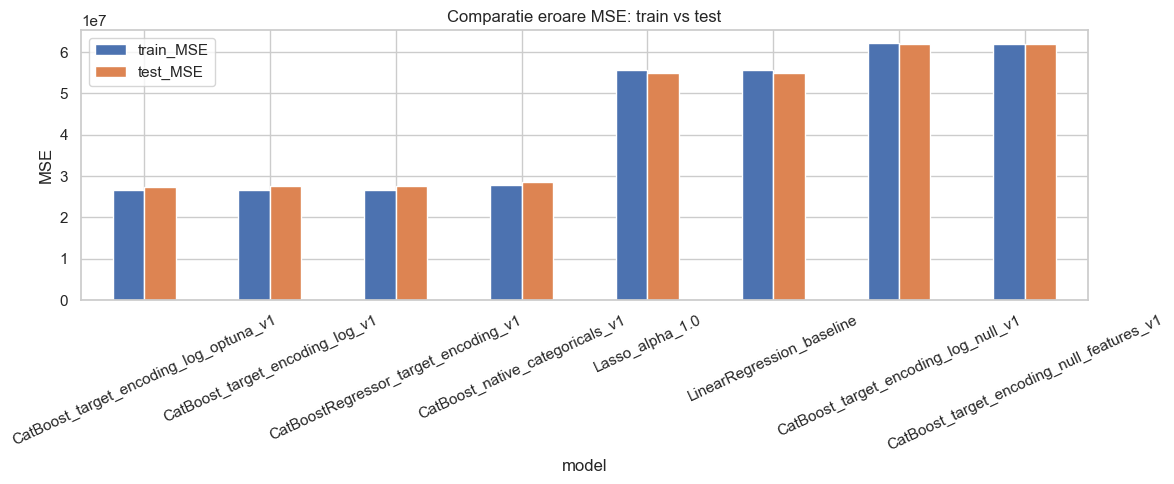

In [33]:
if PLOTS_AVAILABLE:
    plot_df = metrics_df.set_index("model")[["train_MSE", "test_MSE"]]
    ax = plot_df.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Comparatie eroare MSE: train vs test")
    ax.set_ylabel("MSE")
    ax.set_xlabel("model")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()


## B6. Analiza erorilor pe test

Alegem modelul cu MSE minim, pentru ca MSE este metrica folosita de Kaggle la regresie. Apoi verificam unde greseste cel mai mult.


In [34]:
best_name = metrics_df.iloc[0]["model"]
best_pred = all_predictions[best_name]
best_model = all_fitted_models[best_name]

error_df = X_test_base.copy()
error_df["salary_true"] = y_test.values
error_df["salary_pred"] = best_pred
error_df["error"] = error_df["salary_pred"] - error_df["salary_true"]
error_df["abs_error"] = error_df["error"].abs()
error_df["squared_error"] = error_df["error"] ** 2
error_df["salary_bin"] = pd.qcut(error_df["salary_true"], q=5, duplicates="drop")

print("Best model dupa MSE:", best_name)
display(error_df.sort_values("squared_error", ascending=False).head(10))
display(error_df.groupby("salary_bin").agg(
    count=("abs_error", "count"),
    MAE=("abs_error", "mean"),
    MSE=("squared_error", "mean"),
    max_abs_error=("abs_error", "max"),
).round(2))


Best model dupa MSE: CatBoost_target_encoding_log_optuna_v1


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,aggregated_score,skill_bracket,remote_work_missing,education_level_ord,company_size_ord,skill_bracket_ord,skills_per_year,experience_x_skills,certifications_per_year,salary_true,salary_pred,error,abs_error,squared_error,salary_bin
11913,Data Scientist,6,PhD,11,Manufacturing,Enterprise,Australia,NaN,2,-0.017035,mid,1,4.0,4.0,1.0,1.833333,66,0.333333,149530,171909.659392,22379.659392,22379.659392,5.008492e+08,"(134038.4, 152483.2]"
14713,Machine Learning Engineer,9,Master,63,Telecom,Large,Canada,NaN,5,0.312257,low,1,3.0,3.0,0.0,7.000000,567,0.555556,182364,203680.293693,21316.293693,21316.293693,4.543844e+08,"(176033.6, 296998.0]"
11998,Data Scientist,16,PhD,1,Government,Enterprise,UK,NaN,0,-1.724331,low,1,4.0,4.0,0.0,0.062500,16,0.000000,197859,217706.559015,19847.559015,19847.559015,3.939256e+08,"(176033.6, 296998.0]"
15061,DevOps Engineer,20,PhD,6,Healthcare,Small,Australia,Yes,3,0.280088,low,0,4.0,1.0,0.0,0.300000,120,0.150000,192403,172920.599448,-19482.400552,19482.400552,3.795639e+08,"(176033.6, 296998.0]"
10448,Backend Developer,5,Master,12,Consulting,Small,Netherlands,Hybrid,4,-0.921646,mid,0,3.0,1.0,1.0,2.400000,60,0.800000,139698,120280.198666,-19417.801334,19417.801334,3.770510e+08,"(134038.4, 152483.2]"
5728,Product Manager,1,High School,4,Telecom,Medium,India,NaN,2,-0.026891,low,1,0.0,2.0,0.0,4.000000,4,2.000000,92856,73497.452226,-19358.547774,19358.547774,3.747534e+08,"(37212.999, 113760.6]"
8406,Data Analyst,2,PhD,13,Education,Small,USA,NaN,3,-0.813256,mid,1,4.0,1.0,1.0,6.500000,26,1.500000,155177,136121.546571,-19055.453429,19055.453429,3.631103e+08,"(152483.2, 176033.6]"
14134,Cybersecurity Analyst,16,Master,7,Government,Small,Canada,Hybrid,4,-0.366788,low,0,3.0,1.0,0.0,0.437500,112,0.250000,161873,180773.701363,18900.701363,18900.701363,3.572365e+08,"(152483.2, 176033.6]"
569,Data Scientist,14,High School,2,Technology,Enterprise,Germany,NaN,3,1.940492,low,1,0.0,4.0,0.0,0.142857,28,0.214286,149707,168545.830140,18838.830140,18838.830140,3.549015e+08,"(134038.4, 152483.2]"
11493,Business Analyst,4,Diploma,3,Retail,Small,Singapore,NaN,3,-0.998462,low,1,1.0,1.0,0.0,0.750000,12,0.750000,63221,81925.684938,18704.684938,18704.684938,3.498652e+08,"(37212.999, 113760.6]"


,count,MAE,MSE,max_abs_error
salary_bin,,,,
"(37212.999, 113760.6]",3200,4196.40,27599556.67,19358.55
"(113760.6, 134038.4]",3200,4032.27,25347582.21,16749.58
"(134038.4, 152483.2]",3200,4210.09,27845640.24,22379.66
"(152483.2, 176033.6]",3200,4156.00,27213681.26,19055.45
"(176033.6, 296998.0]",3200,4304.19,29128679.62,21316.29


## B7. Predictii pentru test privat Kaggle

Kaggle cere formatul:

```text
id,prediction
1,0.0
2,123.45
```

Deci fisierul nostru trebuie sa aiba coloanele `id` si `prediction`, nu `salary`.


In [35]:
if private_test_raw is not None:
    private_features = [c for c in BASE_FEATURES if c in private_test_raw.columns]
    X_private_base = add_regression_base_features(private_test_raw[private_features])

    # Pentru Kaggle preferam modelul ales prin K-Fold si antrenat pe train + test local.
    # Daca sectiunea K-Fold nu a fost rulata, revenim la cel mai bun model de pe split-ul local.
    if "final_cv_model" in globals() and final_cv_model is not None:
        submission_model = final_cv_model
        submission_model_name = best_cv_name
        submission_source = "K-Fold pe train + test local"
    else:
        submission_model = best_model
        submission_model_name = best_name
        submission_source = "test local"

    private_pred = submission_model.predict(X_private_base)

    submission = pd.DataFrame({"prediction": private_pred})
    if "id" in private_test_raw.columns:
        submission.insert(0, "id", private_test_raw["id"])

    submission.to_csv("submission_regression.csv", index=False)
    print("Model folosit pentru submission:", submission_model_name)
    print("Sursa alegerii:", submission_source)
    display(submission.head())
else:
    print("Nu exista CC_private_test.csv")


Model folosit pentru submission: CatBoost_target_encoding_log_optuna_v1
Sursa alegerii: K-Fold pe train + test local


,id,prediction
0,1,155526.302031
1,2,137433.247433
2,3,113907.997404
3,4,120719.450238
4,5,126638.722593


### B7.1. Submission final de regresie pentru Kaggle/Moodle

Pentru predare pastram doua lucruri separate:

- `submission_regression.csv`: generat clasic din modelul ales local in sectiunea B7;
- `submission_regression_final.csv`: varianta finala pentru leaderboard, obtinuta din etapa de perfectionare `25% CatBoost pseudo + 75% LightGBM pseudo`.

Aceasta celula nu relanseaza Optuna. Ea doar copiaza/verifica submission-ul final confirmat si afiseaza formatul cerut de PDF: `id,prediction`.

In [ ]:
FINAL_CONFIRMED_REGRESSION_SOURCE = Path("submission_gm_bestaway_aggbins_keepraw_w0p05.csv")
FINAL_REGRESSION_SUBMISSION = Path("submission_regression_final.csv")

if FINAL_CONFIRMED_REGRESSION_SOURCE.exists():
    final_submission = pd.read_csv(FINAL_CONFIRMED_REGRESSION_SOURCE)
    final_submission.to_csv(FINAL_REGRESSION_SUBMISSION, index=False)
    final_note = "best-away + 5% LightGBM data-centric aggbins_keepraw, confirmat ca usor mai bun pe Kaggle"
elif Path("submission_gm_away75_alpha_m0p05.csv").exists():
    final_submission = pd.read_csv("submission_gm_away75_alpha_m0p05.csv")
    final_submission.to_csv(FINAL_REGRESSION_SUBMISSION, index=False)
    final_note = "fallback: best-away alpha -0.05, scor Kaggle 268.429M"
elif Path("submission_regression.csv").exists():
    final_submission = pd.read_csv("submission_regression.csv")
    final_submission.to_csv(FINAL_REGRESSION_SUBMISSION, index=False)
    final_note = "fallback: modelul ales local in B7"
else:
    raise FileNotFoundError("Nu exista nici submission-ul final GM, nici submission_regression.csv")

if list(final_submission.columns) != ["id", "prediction"]:
    raise ValueError("Submission-ul final trebuie sa aiba exact coloanele id,prediction")

known_score = REGRESSION_KAGGLE_SCORES.get(FINAL_CONFIRMED_REGRESSION_SOURCE.name)
print("Saved:", FINAL_REGRESSION_SUBMISSION)
print("Strategie:", final_note)
print("Scor Kaggle cunoscut pentru sursa finala:", known_score if known_score is not None else "de completat dupa ultimul upload")
display(final_submission.head())
display(final_submission["prediction"].describe().to_frame("prediction"))


# PARTEA C - CLASIFICARE

Tinta de clasificare este `vacation`, cu clasele `No Vacation`, `Small`, `Medium`, `Large`. Conform PDF-ului, cerinta minima este un **DecisionTreeClassifier** ca baseline si cel putin un experiment in care variem un hiperparametru al arborelui.

Pentru compatibilitate cu `CC_private_test.csv`, nu folosim `salary` ca feature, deoarece nu exista in testul privat. Folosim doar coloanele disponibile si in privat.


## C1. EDA specific pentru clasificare

Pentru clasificare ne intereseaza trei lucruri:

- echilibrul claselor `vacation`;
- legatura dintre cateva atribute numerice si clase;
- relatia dintre categorice importante si clase.

Aceasta sectiune completeaza EDA-ul general din partea A.


In [ ]:
classification_balance = pd.concat([
    train_raw[CLASSIFICATION_TARGET].value_counts().rename("count"),
    (train_raw[CLASSIFICATION_TARGET].value_counts(normalize=True) * 100).round(2).rename("percent")
], axis=1)

display(classification_balance)

classification_numeric_cols = [
    c for c in ["experience_years", "skills_count", "certifications", "total_days_worked", "aggregated_score"]
    if c in train_raw.columns
]
classification_numeric_by_class = train_raw.groupby(CLASSIFICATION_TARGET)[classification_numeric_cols].mean().round(3)
display(classification_numeric_by_class)

for col in ["education_level", "skill_bracket", "company_size", "remote_work"]:
    if col in train_raw.columns:
        print(f"\nDistributie {col} conditionata de vacation (% pe rand):")
        display((pd.crosstab(train_raw[CLASSIFICATION_TARGET], train_raw[col], normalize="index") * 100).round(2))

if 'PLOTS_AVAILABLE' not in globals():
    PLOTS_AVAILABLE = False

if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    classification_balance["count"].plot(kind="bar", ax=axes[0], title="Echilibrul claselor vacation")
    train_raw.boxplot(column="aggregated_score", by=CLASSIFICATION_TARGET, ax=axes[1])
    axes[1].set_title("aggregated_score pe clase")
    axes[1].set_xlabel("vacation")
    fig.suptitle("")
    plt.tight_layout()
    plt.show()


## C2. Preprocesare pentru clasificare

Pentru baseline-ul de clasificare folosim o preprocesare simpla si explicabila:

- eliminam tinta `vacation`;
- eliminam `salary`, deoarece nu exista in testul privat si ar produce un model imposibil de folosit pe Kaggle;
- pastram doar coloane disponibile in `CC_private_test.csv`;
- imputam numericele cu mediana;
- imputam categoricele cu `Missing` si aplicam `OneHotEncoder`;
- encodam tinta cu `LabelEncoder`.


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

CLASSIFICATION_FEATURES = [
    c for c in train_raw.columns
    if c != CLASSIFICATION_TARGET and private_test_raw is not None and c in private_test_raw.columns
]
CLASSIFICATION_FEATURES = [c for c in CLASSIFICATION_FEATURES if c != REGRESSION_TARGET]

X_train_classification = train_raw[CLASSIFICATION_FEATURES].copy()
y_train_classification_raw = train_raw[CLASSIFICATION_TARGET].copy()
X_test_classification = test_raw[CLASSIFICATION_FEATURES].copy()
y_test_classification_raw = test_raw[CLASSIFICATION_TARGET].copy()

CLASSIFICATION_NUM_COLS = X_train_classification.select_dtypes(include=[np.number]).columns.tolist()
CLASSIFICATION_CAT_COLS = [c for c in X_train_classification.columns if c not in CLASSIFICATION_NUM_COLS]

classification_label_encoder = LabelEncoder()
y_train_classification = classification_label_encoder.fit_transform(y_train_classification_raw)
y_test_classification = classification_label_encoder.transform(y_test_classification_raw)

classification_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), CLASSIFICATION_NUM_COLS),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder()),
    ]), CLASSIFICATION_CAT_COLS),
])

print("Features clasificare:", CLASSIFICATION_FEATURES)
print("Numerice:", CLASSIFICATION_NUM_COLS)
print("Categorice:", CLASSIFICATION_CAT_COLS)
print("Clase vacation:", list(classification_label_encoder.classes_))


## C3. Baseline DecisionTreeClassifier si variatie de hiperparametri

PDF-ul cere un arbore de decizie pentru baseline si minim o variatie de hiperparametru. Aici comparam:

- un `DummyClassifier`, ca reper underfit;
- mai multe variante de `DecisionTreeClassifier`, variind `max_depth` si `min_samples_leaf`.

Raportam `accuracy`, dar si `precision`, `recall`, `F1 macro` si `F1 weighted`, deoarece clasele nu sunt perfect echilibrate.


In [ ]:
classification_results = []
classification_predictions = {}
classification_models = {}


def classification_metric_row(name, model):
    model.fit(X_train_classification, y_train_classification)
    pred = model.predict(X_test_classification)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test_classification, pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test_classification, pred, average="weighted", zero_division=0
    )
    classification_predictions[name] = pred
    classification_models[name] = model
    return {
        "model": name,
        "accuracy": accuracy_score(y_test_classification, pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

classification_results.append(classification_metric_row(
    "Dummy_most_frequent",
    DummyClassifier(strategy="most_frequent"),
))

for max_depth, min_leaf in [(4, 20), (6, 20), (8, 30), (10, 50), (None, 100)]:
    clf = Pipeline([
        ("preprocess", classification_preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ])
    classification_results.append(classification_metric_row(
        f"DecisionTree_depth{max_depth}_leaf{min_leaf}", clf
    ))

classification_metrics_df = pd.DataFrame(classification_results).sort_values("accuracy", ascending=False)
display(classification_metrics_df)
classification_metrics_df.to_csv("classification_baseline_results.csv", index=False)

best_classification_name = classification_metrics_df.iloc[0]["model"]
best_classification_pred = classification_predictions[best_classification_name]
print("Cel mai bun baseline de clasificare:", best_classification_name)
print("Confusion matrix, ordinea claselor:", list(classification_label_encoder.classes_))
display(pd.DataFrame(
    confusion_matrix(y_test_classification, best_classification_pred),
    index=classification_label_encoder.classes_,
    columns=classification_label_encoder.classes_,
))
print(classification_report(
    y_test_classification,
    best_classification_pred,
    target_names=classification_label_encoder.classes_,
    zero_division=0,
))


## C4. Predictii private pentru clasificare

Pentru submission, reantrenam cel mai bun arbore pe `train + test local`, deoarece ambele contin eticheta `vacation`. Apoi prezicem pe `CC_private_test.csv` si salvam un CSV cu formatul `id,prediction`.


In [ ]:
if private_test_raw is not None:
    X_all_classification = pd.concat([X_train_classification, X_test_classification], ignore_index=True)
    y_all_classification = classification_label_encoder.transform(
        pd.concat([y_train_classification_raw, y_test_classification_raw], ignore_index=True)
    )

    final_classification_model = classification_models[best_classification_name]
    final_classification_model.fit(X_all_classification, y_all_classification)

    private_classification_pred = classification_label_encoder.inverse_transform(
        final_classification_model.predict(private_test_raw[CLASSIFICATION_FEATURES])
    )
    submission_classification = pd.DataFrame({
        "id": private_test_raw["id"],
        "prediction": private_classification_pred,
    })
    submission_classification.to_csv("submission_classification_baseline.csv", index=False)
    display(submission_classification.head())
    print("Am salvat submission_classification_baseline.csv")
